In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Bibliotecas

# Importando bases

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path1 = '/content/drive/MyDrive/Análise de dados (2025.2)/Trabalho Final/train.csv'
file_path2 = '/content/drive/MyDrive/Análise de dados (2025.2)/Trabalho Final/test.csv'
file_path3 = '/content/drive/MyDrive/Análise de dados (2025.2)/Trabalho Final/sample_submission.csv'

df_train = pd.read_csv(file_path1)
df_test = pd.read_csv(file_path2)
df_sub = pd.read_csv(file_path3)


# Dicionário de dados

In [ ]:
# --- Dicionário de descrições para cada variável ---
descricoes = {
    "PassengerId": "Identificador único de cada passageiro a bordo (formato: grupo_pessoa)",
    "HomePlanet": "Planeta de origem do passageiro (ex: Europa, Earth, Mars)",
    "CryoSleep": "Indica se o passageiro estava em sono criogênico durante a viagem (True = sim, False = não)",
    "Cabin": "Identificação da cabine do passageiro (contém o número, lado e deck — ex: B/0/P)",
    "Destination": "Destino final da viagem interestelar (ex: TRAPPIST-1e, PSO J318.5-22, 55 Cancri e)",
    "Age": "Idade do passageiro (em anos)",
    "VIP": "Indica se o passageiro pagou por privilégios VIP (True = sim, False = não)",
    "RoomService": "Valor gasto pelo passageiro com serviço de quarto (em créditos espaciais)",
    "FoodCourt": "Valor gasto na praça de alimentação da nave (em créditos espaciais)",
    "ShoppingMall": "Valor gasto em lojas a bordo (em créditos espaciais)",
    "Spa": "Valor gasto com serviços de spa (em créditos espaciais)",
    "VRDeck": "Valor gasto com entretenimento de realidade virtual (em créditos espaciais)",
    "Name": "Nome completo do passageiro",
    "Transported": "Indica se o passageiro foi transportado para outra dimensão (True = sim, False = não)"
}

# --- Criar DataFrame base ---
import numpy as np
data_dict = pd.DataFrame({
    "Variável": df_train.columns,
    "Descrição": [descricoes.get(col, "") for col in df_train.columns],
    "Tipo": [df_train[col].dtype for col in df_train.columns],
    "Mensuração": [
        "Categórica" if df_train[col].dtype == 'object' or df_train[col].nunique() < 10 else "Numérica"
        for col in df_train.columns
    ],
    "Valores possíveis": [
        df_train[col].unique()[:10] if df_train[col].nunique() <= 10 or df_train[col].dtype == 'object' else f"{df_train[col].min()} – {df_train[col].max()}"
        for col in df_train.columns
    ]
})

# Converter lists/arrays and non-numeric min/max to strings
data_dict["Valores possíveis"] = data_dict["Valores possíveis"].apply(
    lambda x: ', '.join(map(str, x)) if isinstance(x, (list, np.ndarray, pd.Series)) else str(x)
)


# --- Estilizar a exibição no notebook ---
styled_dict = (
    data_dict.style
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#007acc'),
                                     ('color', 'white'),
                                     ('text-align', 'center'),
                                     ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                     ('border', '1px solid #ccc'),
                                     ('padding', '6px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'),
                                        ('margin', '10px 0'),
                                        ('width', '100%'),
                                        ('font-family', 'Arial'),
                                        ('font-size', '13px')]},
    ])
    .set_caption("Dicionário de Dados — Spaceship Titanic (Português)")
)

styled_dict

,Variável,Descrição,Tipo,Mensuração,Valores possíveis
0,PassengerId,Identificador único de cada passageiro a bordo (formato: grupo_pessoa),object,Categórica,"0001_01, 0002_01, 0003_01, 0003_02, 0004_01, 0005_01, 0006_01, 0006_02, 0007_01, 0008_01"
1,HomePlanet,"Planeta de origem do passageiro (ex: Europa, Earth, Mars)",object,Categórica,"Europa, Earth, Mars, nan"
2,CryoSleep,"Indica se o passageiro estava em sono criogênico durante a viagem (True = sim, False = não)",object,Categórica,"False, True, nan"
3,Cabin,"Identificação da cabine do passageiro (contém o número, lado e deck — ex: B/0/P)",object,Categórica,"B/0/P, F/0/S, A/0/S, F/1/S, F/0/P, F/2/S, G/0/S, F/3/S, B/1/P, F/1/P"
4,Destination,"Destino final da viagem interestelar (ex: TRAPPIST-1e, PSO J318.5-22, 55 Cancri e)",object,Categórica,"TRAPPIST-1e, PSO J318.5-22, 55 Cancri e, nan"
5,Age,Idade do passageiro (em anos),float64,Numérica,0.0 – 79.0
6,VIP,"Indica se o passageiro pagou por privilégios VIP (True = sim, False = não)",object,Categórica,"False, True, nan"
7,RoomService,Valor gasto pelo passageiro com serviço de quarto (em créditos espaciais),float64,Numérica,0.0 – 14327.0
8,FoodCourt,Valor gasto na praça de alimentação da nave (em créditos espaciais),float64,Numérica,0.0 – 29813.0
9,ShoppingMall,Valor gasto em lojas a bordo (em créditos espaciais),float64,Numérica,0.0 – 23492.0


### OBS: É possível que durante o desenvolvimento do projeto troquemos o tipo e nome de algumas variáveis para limpeza do dataframe.

### Também é possível que os resultados mostrados nos valores possíveis estejam incompletos devido à grande quantidade de dados diferentes e dados não numéricos.

# Análise Inicial

## df_train

In [ ]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
df_train.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


Notavelmente há algum problema com relação aos IDs dos passageiros, provavelmente da divisão da base de dados.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


Verificam-se algumas discrepâncias com relação aos tipos das variáveis. (ex. CryoSleep = object; deveria ser bool [?])

In [ ]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


Estudar qual a melhor maneira de se realizar a completeza dos dados faltantes

In [ ]:
df_train.duplicated().sum()

np.int64(0)

Aparentemente, não possui duplicatas

## df_test

In [ ]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [ ]:
df_test.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale
4276,9277_01,Earth,True,G/1498/S,PSO J318.5-22,43.0,False,0.0,0.0,0.0,0.0,0.0,Lilace Leonzaley


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


As incongruências persistem

In [ ]:
df_test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [ ]:
df_test.isnull().sum()

,0
PassengerId,0
HomePlanet,87
CryoSleep,93
Cabin,100
Destination,92
Age,91
VIP,93
RoomService,82
FoodCourt,106
ShoppingMall,98


Estudar maneira para realizar a imputação dos dados ausentes.

## df_sub

In [ ]:
df_sub.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [ ]:
df_sub.tail()

,PassengerId,Transported
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False
4276,9277_01,False


In [ ]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  4277 non-null   object
 1   Transported  4277 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 37.7+ KB


Sem dados faltantes; base realmente destinada para testar o modelo (decidir)

# Imputação dos dados faltantes em df_train

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


## HomePlanet

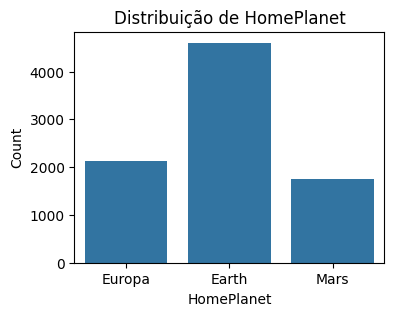

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='HomePlanet')
plt.title('Distribuição de HomePlanet')
plt.xlabel('HomePlanet')
plt.ylabel('Count')
plt.show()

Por ser categórica, optaremos pela substituição pela moda.

In [ ]:
df_train['HomePlanet'] = df_train['HomePlanet'].fillna(df_train['HomePlanet'].mode()[0])

Verificando a quantidade de dados faltantes

In [ ]:
df_train['HomePlanet'].isnull().sum()

np.int64(0)

## CryoSleep

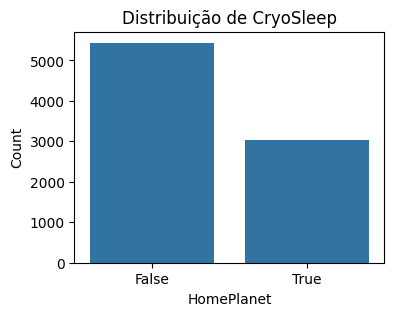

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='CryoSleep')
plt.title('Distribuição de CryoSleep')
plt.xlabel('HomePlanet')
plt.ylabel('Count')
plt.show()

Alterando o tipo de 'CryoSleep' pra booleano e imputando pela moda por serem dados categóricos

In [ ]:
df_train['CryoSleep'] = df_train['CryoSleep'].astype(bool)

df_train['CryoSleep'] = df_train['CryoSleep'].fillna(df_train['CryoSleep'].mode()[0])

Verificando a quantidade de dados faltantes

In [ ]:
df_train['CryoSleep'].isnull().sum()

np.int64(0)

## Cabin

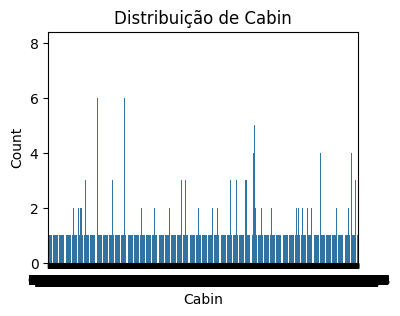

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin')
plt.title('Distribuição de Cabin')
plt.xlabel('Cabin')
plt.ylabel('Count')
plt.show()

A visualização ficou comprometida

In [ ]:
# Separando a coluna 'Cabin' em 'Cabin_Deck', 'Cabin_Num' e 'Cabin_Side'

df_train[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_train['Cabin'].str.split('/', expand=True)

display(df_train[['Cabin', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side']].head())

,Cabin,Cabin_Deck,Cabin_Num,Cabin_Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S


### Cabin_Deck

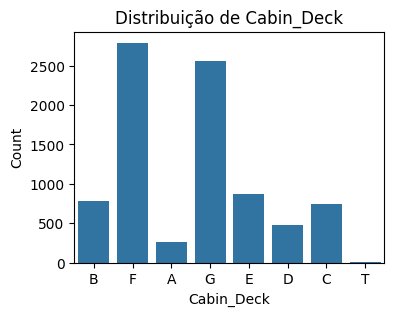

In [ ]:
# distribuição de 'Cabin_Deck'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin_Deck')
plt.title('Distribuição de Cabin_Deck')
plt.xlabel('Cabin_Deck')
plt.ylabel('Count')
plt.show()

In [ ]:
# imputando com a moda (F)
df_train['Cabin_Deck'] = df_train['Cabin_Deck'].fillna(df_train['Cabin_Deck'].mode()[0])

In [ ]:
# verificando dados faltantes
df_train['Cabin_Deck'].isnull().sum()

np.int64(0)

### Cabin_Side

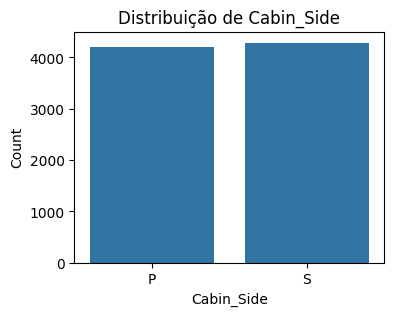

In [ ]:
# distribuição de 'Cabin_Side'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin_Side')
plt.title('Distribuição de Cabin_Side')
plt.xlabel('Cabin_Side')
plt.ylabel('Count')
plt.show()

In [ ]:
df_train['Cabin_Side'].isnull().sum()

np.int64(199)

In [ ]:
# imputando com a moda (F)
df_train['Cabin_Side'] = df_train['Cabin_Side'].fillna(df_train['Cabin_Side'].mode()[0])

In [ ]:
# verificando dados faltantes
df_train['Cabin_Deck'].isnull().sum()

np.int64(0)

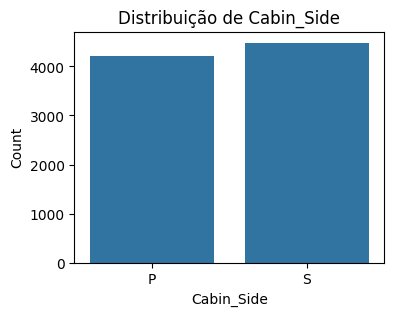

In [ ]:
# distribuição de 'Cabin_Side' após completeza

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin_Side')
plt.title('Distribuição de Cabin_Side')
plt.xlabel('Cabin_Side')
plt.ylabel('Count')
plt.show()

### Cabin_Num

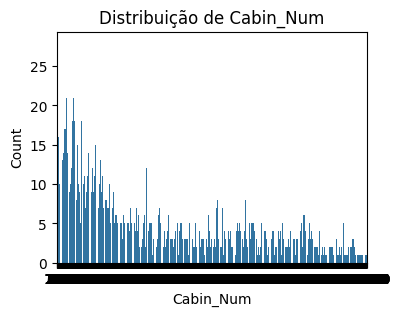

In [ ]:
# Convertendo 'Cabin_Num' para int
df_train['Cabin_Num'] = df_train['Cabin_Num'].astype(float)

# Distribuição de 'Cabin_Num'
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin_Num')
plt.title('Distribuição de Cabin_Num')
plt.xlabel('Cabin_Num')
plt.ylabel('Count')
plt.show()

In [ ]:
# Separando a parte do grupo do PassengerId
df_train['PassengerGroup'] = df_train['PassengerId'].apply(lambda x: x.split('_')[0])

# Exibindo as primeiras linhas para verificar
display(df_train[['PassengerId', 'PassengerGroup', 'Cabin_Num']].head())

,PassengerId,PassengerGroup,Cabin_Num
0,0001_01,0001,0.0
1,0002_01,0002,0.0
2,0003_01,0003,0.0
3,0003_02,0003,0.0
4,0004_01,0004,1.0


In [ ]:
# Convertendo 'PassengerGroup' para numérico
df_train['PassengerGroup'] = pd.to_numeric(df_train['PassengerGroup'], errors='coerce')

# Calculando a correlação entre 'Cabin_Num' e 'PassengerGroup'
correlation = df_train['Cabin_Num'].corr(df_train['PassengerGroup'])

print(f"A correlação entre Cabin_Num e PassengerGroup é: {correlation}")

A correlação entre Cabin_Num e PassengerGroup é: 0.679723036170993


Antes de realizarmos a completeza, é válido explorarmos outros meios para tentar atingir uma melhor correlação

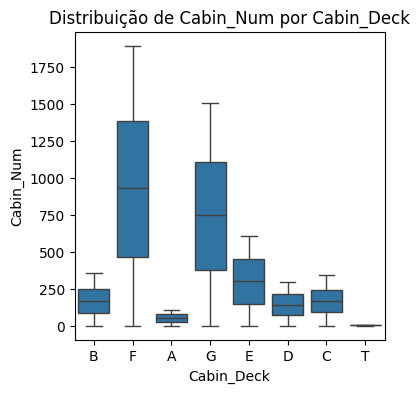

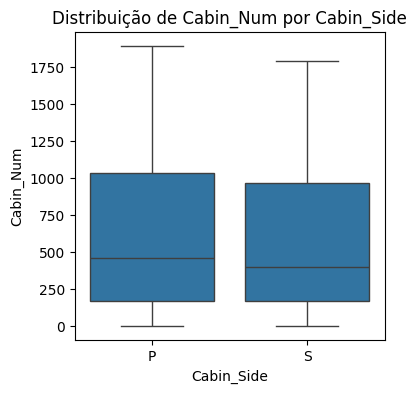

In [ ]:
# Visualizando a distribuição de Cabin_Num por Cabin_Deck
plt.figure(figsize=(4, 4))
sns.boxplot(data=df_train, x='Cabin_Deck', y='Cabin_Num')
plt.title('Distribuição de Cabin_Num por Cabin_Deck')
plt.xlabel('Cabin_Deck')
plt.ylabel('Cabin_Num')
plt.show()

# Visualizando a distribuição de Cabin_Num por Cabin_Side
plt.figure(figsize=(4, 4))
sns.boxplot(data=df_train, x='Cabin_Side', y='Cabin_Num')
plt.title('Distribuição de Cabin_Num por Cabin_Side')
plt.xlabel('Cabin_Side')
plt.ylabel('Cabin_Num')
plt.show()

A variação significativa nas medianas de 'Cabin_Num' entre os diferentes 'Cabin_Decks' (como vimos que alguns decks têm medianas muito diferentes de outros) é um forte indicador de que 'Cabin_Deck' tem uma influência considerável no 'Cabin_Num'. Mesmo sem um único número de correlação, a clara separação das distribuições nos box plots e a diferença nas medianas demonstram uma associação que é provavelmente mais útil para preencher os dados faltantes de 'Cabin_Num' do que apenas usar o 'PassengerGroup'.

In [ ]:
# Calculando a mediana de Cabin_Num por Cabin_Deck
median_cabin_num_by_deck = df_train.groupby('Cabin_Deck')['Cabin_Num'].median()

print("Mediana de Cabin_Num por Cabin_Deck:")
display(median_cabin_num_by_deck)

Mediana de Cabin_Num por Cabin_Deck:


,Cabin_Num
Cabin_Deck,
A,53.5
B,166.0
C,163.0
D,138.0
E,302.0
F,933.5
G,748.0
T,2.0


In [ ]:
# Imputando valores faltantes em 'Cabin_Num' com a mediana por 'Cabin_Deck'
df_train['Cabin_Num'] = df_train.groupby('Cabin_Deck')['Cabin_Num'].transform(lambda x: x.fillna(x.median()))

# Verificando a quantidade de dados faltantes após a imputação
print("\nQuantidade de dados faltantes em 'Cabin_Num' após imputação:")
display(df_train['Cabin_Num'].isnull().sum())


Quantidade de dados faltantes em 'Cabin_Num' após imputação:


np.int64(0)

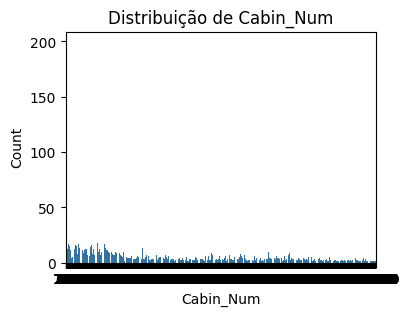

In [ ]:
# Distribuição de 'Cabin_Num'
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Cabin_Num')
plt.title('Distribuição de Cabin_Num')
plt.xlabel('Cabin_Num')
plt.ylabel('Count')
plt.show()

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
# Preenchendo os valores faltantes na coluna 'Cabin' original
# Apenas para as linhas onde 'Cabin' era NaN, construímos a string usando as colunas imputadas
df_train['Cabin'] = df_train.apply(
    lambda row: f"{row['Cabin_Deck']}/{int(row['Cabin_Num'])}/{row['Cabin_Side']}" if pd.isna(row['Cabin']) else row['Cabin'],
    axis=1
)

# Verificando a quantidade de dados faltantes em 'Cabin' após a atualização
print("Quantidade de dados faltantes em 'Cabin' após atualização:")
display(df_train['Cabin'].isnull().sum())

Quantidade de dados faltantes em 'Cabin' após atualização:


np.int64(0)

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


## Destination

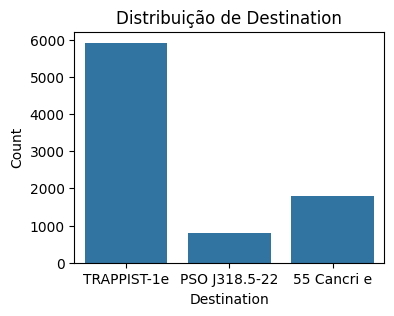

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Destination')
plt.title('Distribuição de Destination')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.show()

Imputando pela moda por serem dados categóricos

In [ ]:
df_train['Destination'] = df_train['Destination'].fillna(df_train['Destination'].mode()[0])

Verificando a quantidade de dados faltantes

In [ ]:
df_train['Destination'].isnull().sum()

np.int64(0)

Replotando o gráfico para visualização de diferenças:

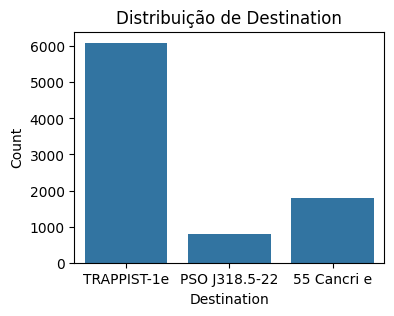

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Destination')
plt.title('Distribuição de Destination')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.show()

## Age

In [ ]:
df_train["Age"] = df_train["Age"].dropna().astype(int)

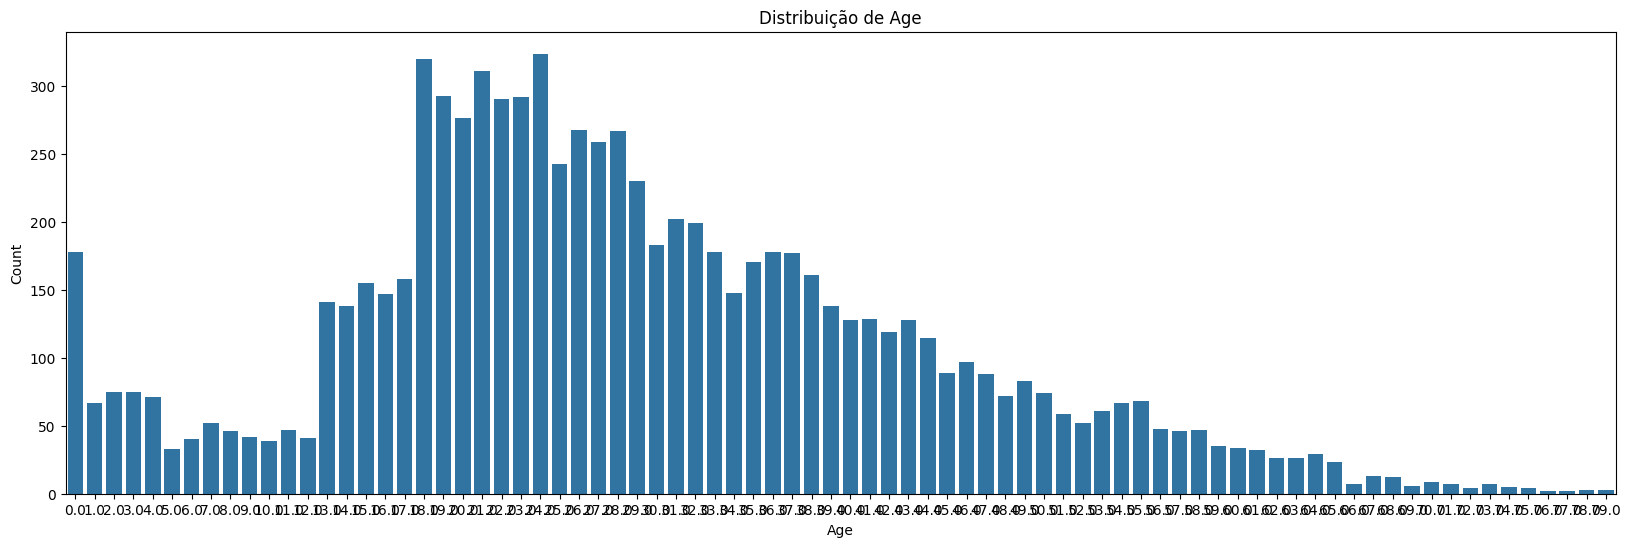

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(data=df_train, x='Age')
plt.title('Distribuição de Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:
# utilizamos o Homeplanet para realizar um groupby junto com idade para formar uma média e preencher os dados faltantes
df_train['Age'] = df_train.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.mean()))

# preenchimento de dados faltantes
df_train['Age'].fillna(df_train['Age'].mean(), inplace=True)


/tmp/ipython-input-2248375186.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Age'].fillna(df_train['Age'].mean(), inplace=True)


In [ ]:
df_train['Age'].isnull().sum()

np.int64(0)

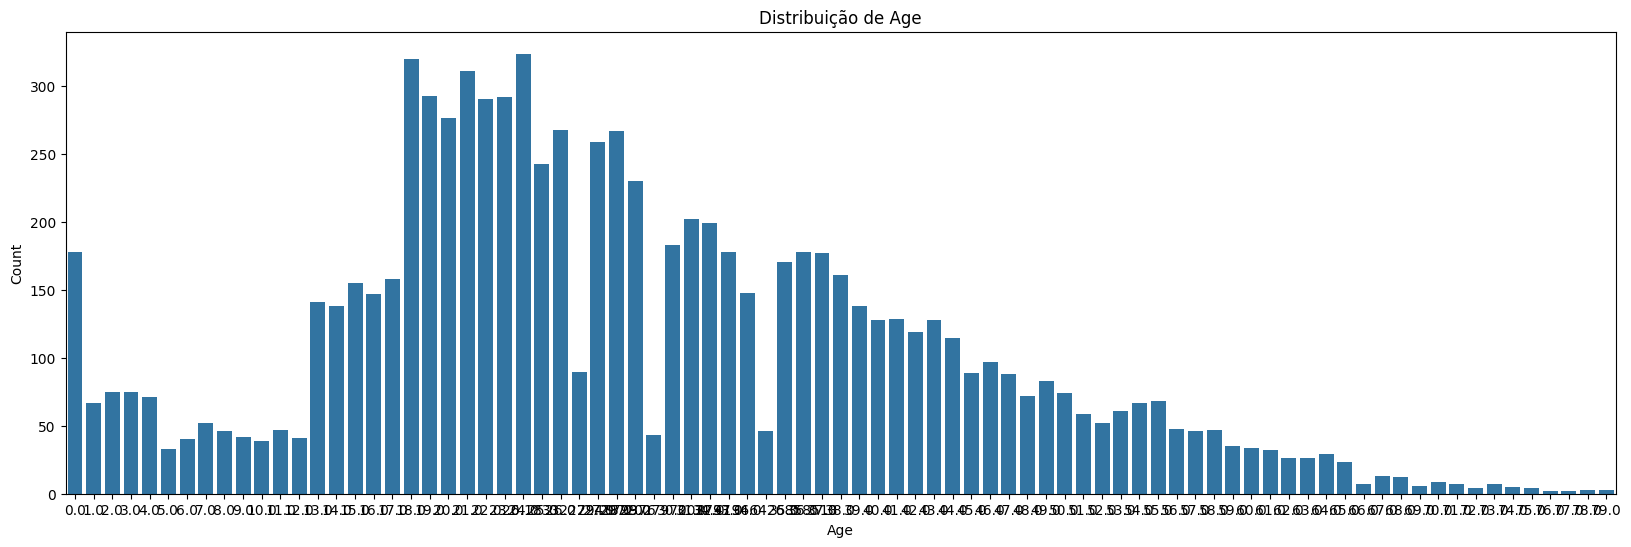

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(data=df_train, x='Age')
plt.title('Distribuição de Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


## Vip

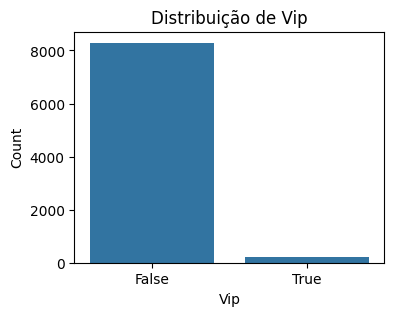

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='VIP')
plt.title('Distribuição de Vip')
plt.xlabel('Vip')
plt.ylabel('Count')
plt.show()

Vamos analisar a relação entre 'VIP' e 'Destination' para ver se podemos usar essa informação para imputar os dados faltantes de forma mais precisa.

In [ ]:
# Analisando a relação entre VIP e Destination
vip_destination_crosstab = pd.crosstab(df_train['VIP'], df_train['HomePlanet'])
display(vip_destination_crosstab)

HomePlanet,Earth,Europa,Mars
VIP,,,
False,4680,1958,1653
True,5,131,63


In [ ]:
vip_destination_crosstab = pd.crosstab(df_train['VIP'], df_train['Destination'])
display(vip_destination_crosstab)

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
VIP,,,
False,1692,756,5843
True,65,18,116


In [ ]:
vip_destination_crosstab = pd.crosstab(df_train['VIP'], [df_train['HomePlanet'], df_train['Destination']])
display(vip_destination_crosstab)

HomePlanet        Earth                                Europa                \
Destination 55 Cancri e PSO J318.5-22 TRAPPIST-1e 55 Cancri e PSO J318.5-22   
VIP                                                                           
False               696           708        3276         807             9   
True                  2             0           3          63            10   

HomePlanet                     Mars                            
Destination TRAPPIST-1e 55 Cancri e PSO J318.5-22 TRAPPIST-1e  
VIP                                                            
False              1142         189            39        1425  
True                 58           0             8          55

In [ ]:
# Imputando valores faltantes em 'VIP' com a moda por 'HomePlanet' e 'Destination'
df_train['VIP'] = df_train.groupby(['HomePlanet', 'Destination'])['VIP'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False))

/tmp/ipython-input-2161750405.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['VIP'] = df_train.groupby(['HomePlanet', 'Destination'])['VIP'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False))


Verificando a quantidade de dados faltantes em 'VIP' após imputação:

In [ ]:
df_train['VIP'].isnull().sum()

np.int64(0)

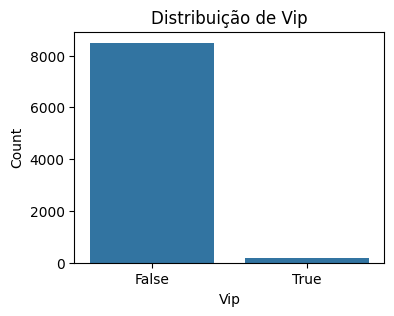

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='VIP')
plt.title('Distribuição de Vip')
plt.xlabel('Vip')
plt.ylabel('Count')
plt.show()

## RoomService

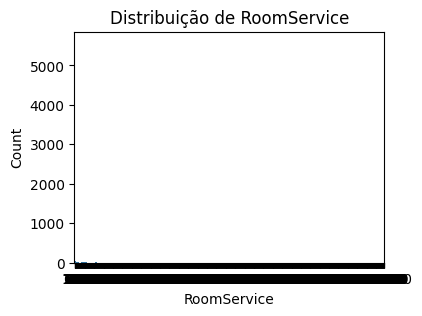

In [ ]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='RoomService')
plt.title('Distribuição de RoomService')
plt.xlabel('RoomService')
plt.ylabel('Count')
plt.show()

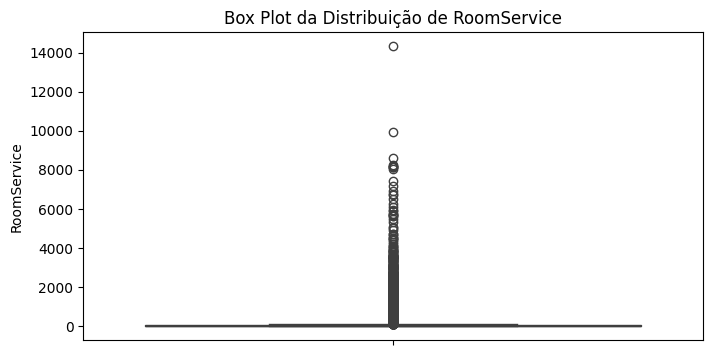

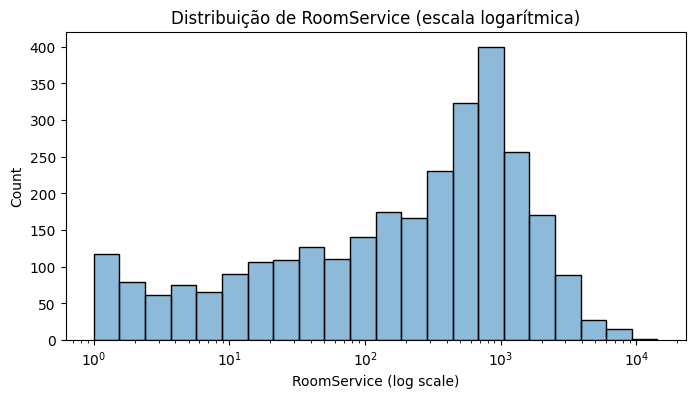

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train, y='RoomService')
plt.title('Box Plot da Distribuição de RoomService')
plt.ylabel('RoomService')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='RoomService', kde=True, log_scale=True)
plt.title('Distribuição de RoomService (escala logarítmica)')
plt.xlabel('RoomService (log scale)')
plt.ylabel('Count')
plt.show()

Number of passengers with 0 RoomService spending: 5577
Number of passengers with non-zero RoomService spending: 2935


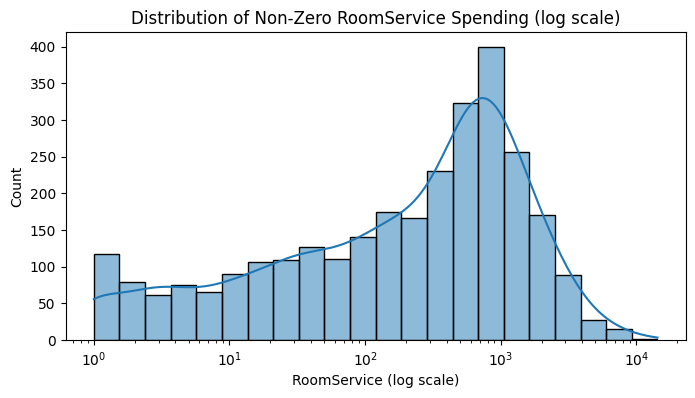

In [ ]:
zero_roomservice = df_train[df_train['RoomService'] == 0]['RoomService'].count()
non_zero_roomservice = df_train[df_train['RoomService'] > 0]['RoomService']

print(f"Number of passengers with 0 RoomService spending: {zero_roomservice}")
print(f"Number of passengers with non-zero RoomService spending: {non_zero_roomservice.count()}")

if non_zero_roomservice.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_roomservice, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero RoomService Spending (log scale)')
    plt.xlabel('RoomService (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero RoomService spending to visualize.")

Tentamos vários modelos de gráfico, mas a visualização não ficou tão boa.

In [ ]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] # Colunas nas quais há gastos (buscando alguma correlação para imputação)
correlation_matrix = df_train[spending_cols].corr()

print("Correlation matrix of spending columns:")
display(correlation_matrix)

Correlation matrix of spending columns:


,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
RoomService,1.000000,-0.015889,0.054480,0.010080,-0.019581
FoodCourt,-0.015889,1.000000,-0.014228,0.221891,0.227995
ShoppingMall,0.054480,-0.014228,1.000000,0.013879,-0.007322
Spa,0.010080,0.221891,0.013879,1.000000,0.153821
VRDeck,-0.019581,0.227995,-0.007322,0.153821,1.000000


Nota-se uma baixa correlação com outras colunas de gastos. Portanto, optamos por outro caminho: a média entre um groupby de (homeplanet e destination) e (roomservice).

In [ ]:
# Calcuando a média RoomService com um groupby 'HomePlanet' e 'Destination'
median_roomservice_by_group = df_train.groupby(['HomePlanet', 'Destination'])['RoomService'].median()

print("Median RoomService by HomePlanet and Destination:")
display(median_roomservice_by_group)

Median RoomService by HomePlanet and Destination:


HomePlanet  Destination  
Earth       55 Cancri e        0.0
            PSO J318.5-22      0.0
            TRAPPIST-1e        0.0
Europa      55 Cancri e        0.0
            PSO J318.5-22      0.0
            TRAPPIST-1e        0.0
Mars        55 Cancri e        4.0
            PSO J318.5-22    192.0
            TRAPPIST-1e       23.0
Name: RoomService, dtype: float64

In [ ]:
# Imputando os dados.
df_train['RoomService'] = df_train.groupby(['HomePlanet', 'Destination'])['RoomService'].transform(lambda x: x.fillna(x.median()))

Verificando a quantidade de dados faltantes em 'RoomService' após imputação:

In [ ]:
df_train['RoomService'].isnull().sum()

np.int64(0)

Plotando os gráficos

Number of passengers with 0 RoomService spending: 5722
Number of passengers with non-zero RoomService spending: 2971


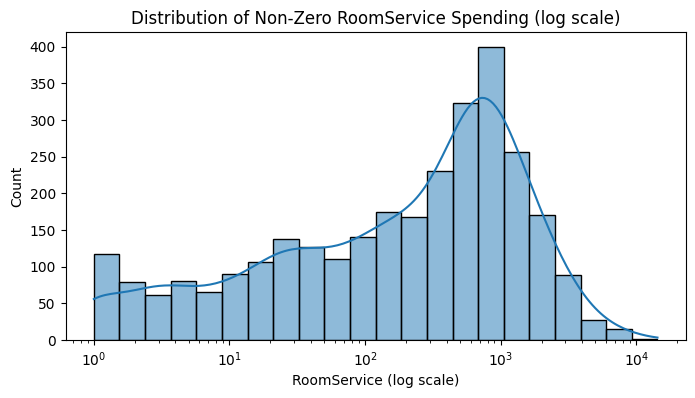

In [ ]:
zero_roomservice = df_train[df_train['RoomService'] == 0]['RoomService'].count()
non_zero_roomservice = df_train[df_train['RoomService'] > 0]['RoomService']

print(f"Number of passengers with 0 RoomService spending: {zero_roomservice}")
print(f"Number of passengers with non-zero RoomService spending: {non_zero_roomservice.count()}")


if non_zero_roomservice.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_roomservice, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero RoomService Spending (log scale)')
    plt.xlabel('RoomService (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero RoomService spending to visualize.")

Dentre todos os tipos de gráficos feitos, o que teve uma melhor visualização foi esse em escala logarítmica. A visualização requer um pouco de atenção, pois a maior concentração de dados está entre o 10^3 e o 10^4. Por isso, a distribuição é maior nesses pontos. Apesar de tudo, nota-se que a maior contagem de serviço de quarto está nos arredores do número 1000.

## FoodCourt

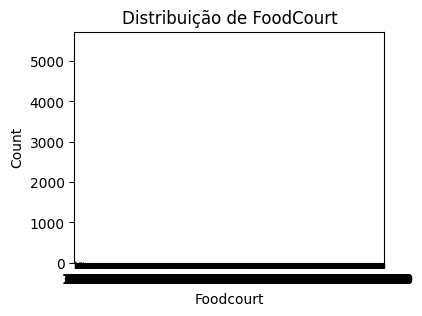

In [ ]:
# distribuição de frequência 'FoodCourt'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='FoodCourt')
plt.title('Distribuição de FoodCourt')
plt.xlabel('Foodcourt')
plt.ylabel('Count')
plt.show()

A ilegibilidade dá-se pela alta distinção dos valores em 'FoodCourt'.

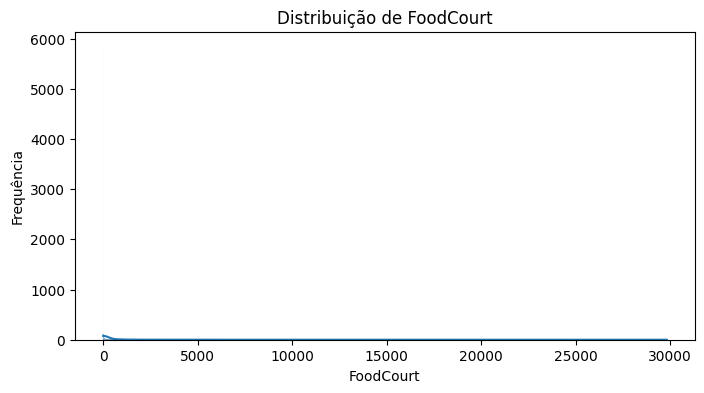

In [ ]:
# Distribuição de 'FoodCourt' com histograma
plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='FoodCourt', kde=True)
plt.title('Distribuição de FoodCourt')
plt.xlabel('FoodCourt')
plt.ylabel('Frequência')
plt.show()

Number of passengers with 0 FoodCourt spending: 5456
Number of passengers with non-zero FoodCourt spending: 3054


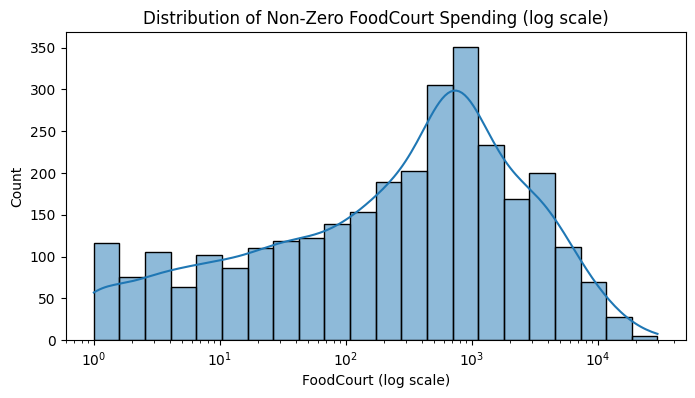

In [ ]:
zero_foodcourt = df_train[df_train['FoodCourt'] == 0]['FoodCourt'].count()
non_zero_foodcourt = df_train[df_train['FoodCourt'] > 0]['FoodCourt']

print(f"Number of passengers with 0 FoodCourt spending: {zero_foodcourt}")
print(f"Number of passengers with non-zero FoodCourt spending: {non_zero_foodcourt.count()}")


if non_zero_foodcourt.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_foodcourt, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero FoodCourt Spending (log scale)')
    plt.xlabel('FoodCourt (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero FoodCourt spending to visualize.")

De maneira semelhante a "RoomService", a visualização em escala logarítimica foi a melhor maneira de representação dos dados em 'FoodCourt'.

- Concentração de gastos: A maior concentração de gastos (contagem mais alta) parece estar na faixa entre 10² e 10³ na escala original (que corresponde a 2 e 3 na escala logarítmica). Isso sugere que, entre os passageiros que gastaram algo na praça de alimentação, a maioria gastou valores na casa das centenas.
- Distribuição: A distribuição dos gastos na escala logarítmica parece ter uma forma aproximadamente unimodal (um pico principal), embora possa haver uma leve inclinação ou cauda para a direita, indicando que há alguns passageiros com gastos significativamente mais altos.
- Comparação com RoomService — também organizado na forma logarítmica: Se compararmos com o gráfico de 'RoomService' (também em escala logarítmica), podemos notar semelhanças na forma da distribuição dos gastos, sugerindo padrões de consumo parecidos entre os passageiros que utilizam esses serviços. No entanto, os picos de frequência podem estar em faixas de valores ligeiramente diferentes para cada serviço.

In [ ]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] # Colunas nas quais há gastos (buscando alguma correlação para imputação)
correlation_matrix = df_train[spending_cols].corr()

print("Correlation matrix of spending columns:")
display(correlation_matrix)

Correlation matrix of spending columns:


,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
RoomService,1.000000,-0.015500,0.053616,0.009615,-0.019562
FoodCourt,-0.015500,1.000000,-0.014228,0.221891,0.227995
ShoppingMall,0.053616,-0.014228,1.000000,0.013879,-0.007322
Spa,0.009615,0.221891,0.013879,1.000000,0.153821
VRDeck,-0.019562,0.227995,-0.007322,0.153821,1.000000


In [ ]:
# Calculando a mediana FoodCourt com um groupby 'HomePlanet' e 'Destination'
median_foodcourt_by_group = df_train.groupby(['HomePlanet', 'Destination'])['FoodCourt'].median()

print("Median FoodCourt by HomePlanet and Destination:")
display(median_foodcourt_by_group)

Median FoodCourt by HomePlanet and Destination:


HomePlanet  Destination  
Earth       55 Cancri e       0.0
            PSO J318.5-22     0.0
            TRAPPIST-1e       0.0
Europa      55 Cancri e       0.0
            PSO J318.5-22    24.5
            TRAPPIST-1e      53.0
Mars        55 Cancri e       0.0
            PSO J318.5-22     0.0
            TRAPPIST-1e       0.0
Name: FoodCourt, dtype: float64

In [ ]:
# Imputando os dados
df_train['FoodCourt'] = df_train.groupby(['HomePlanet', 'Destination'])['FoodCourt'].transform(lambda x: x.fillna(x.median()))

Verificando a quantidade de dados faltantes em 'FoodCourt' após imputação:

In [ ]:
df_train['FoodCourt'].isnull().sum()

np.int64(0)

Number of passengers with 0 FoodCourt spending: 5609
Number of passengers with non-zero FoodCourt spending: 3084


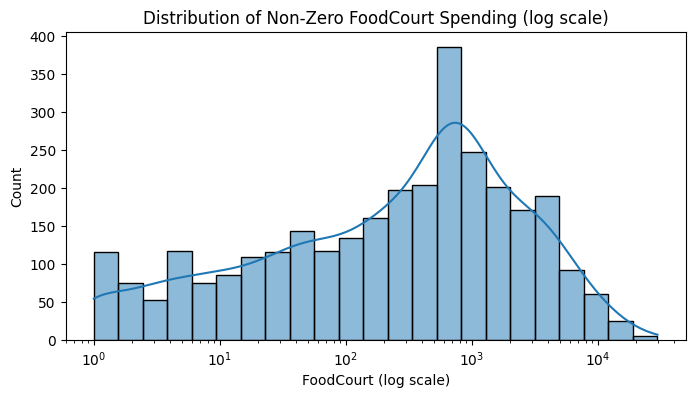

In [ ]:
# Distribuição após imputação

zero_foodcourt = df_train[df_train['FoodCourt'] == 0]['FoodCourt'].count()
non_zero_foodcourt = df_train[df_train['FoodCourt'] > 0]['FoodCourt']

print(f"Number of passengers with 0 FoodCourt spending: {zero_foodcourt}")
print(f"Number of passengers with non-zero FoodCourt spending: {non_zero_foodcourt.count()}")


if non_zero_foodcourt.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_foodcourt, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero FoodCourt Spending (log scale)')
    plt.xlabel('FoodCourt (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero FoodCourt spending to visualize.")

É importante notar que o gráfico mostra a distribuição apenas dos valores não-zero. O número de passageiros com gasto zero em 'FoodCourt' ainda é significativo (5609 após a imputação), o que também influencia a distribuição geral da coluna.

Portanto, a concentração em torno de 10²-10³ no gráfico logarítmico parece razoável para os passageiros que de fato gastaram em 'FoodCourt', considerando a natureza dos dados e a estratégia de imputação utilizada.

## ShoppingMall

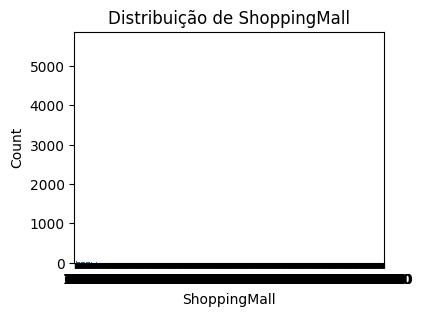

In [ ]:
# distribuição de frequência 'ShoppingMall'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='ShoppingMall')
plt.title('Distribuição de ShoppingMall')
plt.xlabel('ShoppingMall')
plt.ylabel('Count')
plt.show()

Padrão recorrente das 'Spending_cols' - colunas de gasto

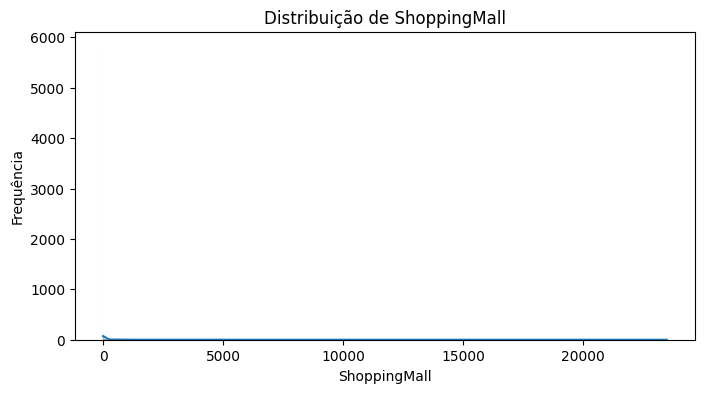

In [ ]:
# Distribuição de 'ShoppingMall' com histograma

plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='ShoppingMall', kde=True)
plt.title('Distribuição de ShoppingMall')
plt.xlabel('ShoppingMall')
plt.ylabel('Frequência')
plt.show()

Number of passengers with 0 ShoppingMall spending: 5587
Number of passengers with non-zero ShoppingMall spending: 2898


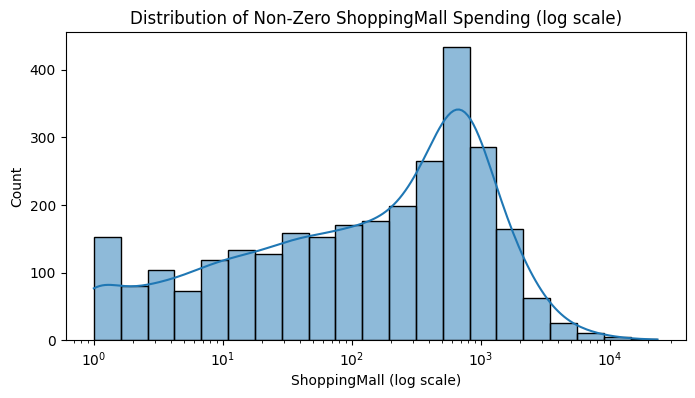

In [ ]:
zero_shoppingmall = df_train[df_train['ShoppingMall'] == 0]['ShoppingMall'].count()
non_zero_shoppingmall = df_train[df_train['ShoppingMall'] > 0]['ShoppingMall']

print(f"Number of passengers with 0 ShoppingMall spending: {zero_shoppingmall}")
print(f"Number of passengers with non-zero ShoppingMall spending: {non_zero_shoppingmall.count()}")


if non_zero_shoppingmall.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_shoppingmall, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero ShoppingMall Spending (log scale)')
    plt.xlabel('ShoppingMall (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero ShoppingMall spending to visualize.")

In [ ]:
# Calculando a mediana ShoppingMall com um groupby 'HomePlanet' e 'Destination'
median_shoppingmall_by_group = df_train.groupby(['HomePlanet', 'Destination'])['ShoppingMall'].median()

print("Median ShoppingMall by HomePlanet and Destination:")
display(median_shoppingmall_by_group)

Median ShoppingMall by HomePlanet and Destination:


HomePlanet  Destination  
Earth       55 Cancri e       0.0
            PSO J318.5-22     0.0
            TRAPPIST-1e       0.0
Europa      55 Cancri e       0.0
            PSO J318.5-22     0.0
            TRAPPIST-1e       0.0
Mars        55 Cancri e       0.0
            PSO J318.5-22    71.0
            TRAPPIST-1e       0.0
Name: ShoppingMall, dtype: float64

In [ ]:
# Imputando os dados.
df_train['ShoppingMall'] = df_train.groupby(['HomePlanet', 'Destination'])['ShoppingMall'].transform(lambda x: x.fillna(x.median()))

Verificando a quantidade de dados faltantes em 'ShoppingMall' após imputação


In [ ]:
df_train['ShoppingMall'].isnull().sum()

np.int64(0)

Number of passengers with 0 FoodCourt spending: 5609
Number of passengers with non-zero FoodCourt spending: 3084


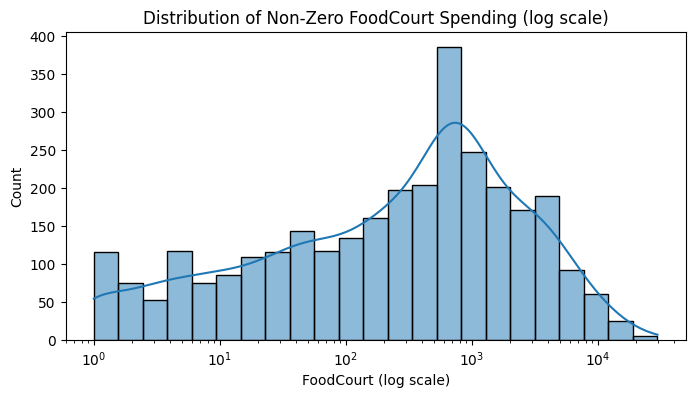

In [ ]:
# Distribuição após imputação

zero_foodcourt = df_train[df_train['FoodCourt'] == 0]['FoodCourt'].count()
non_zero_foodcourt = df_train[df_train['FoodCourt'] > 0]['FoodCourt']

print(f"Number of passengers with 0 FoodCourt spending: {zero_foodcourt}")
print(f"Number of passengers with non-zero FoodCourt spending: {non_zero_foodcourt.count()}")


if non_zero_foodcourt.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_foodcourt, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero FoodCourt Spending (log scale)')
    plt.xlabel('FoodCourt (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero FoodCourt spending to visualize.")

Number of passengers with 0 ShoppingMall spending after imputation: 5795
Number of passengers with non-zero ShoppingMall spending after imputation: 2898


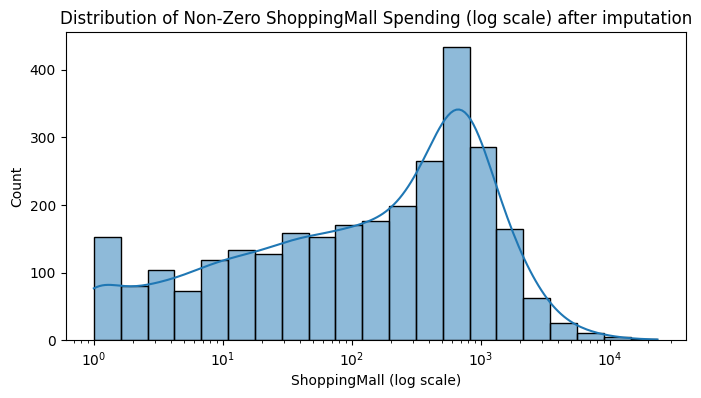

In [ ]:
# Distribuição após imputação para ShoppingMall

zero_shoppingmall_after_imputation = df_train[df_train['ShoppingMall'] == 0]['ShoppingMall'].count()
non_zero_shoppingmall_after_imputation = df_train[df_train['ShoppingMall'] > 0]['ShoppingMall']

print(f"Number of passengers with 0 ShoppingMall spending after imputation: {zero_shoppingmall_after_imputation}")
print(f"Number of passengers with non-zero ShoppingMall spending after imputation: {non_zero_shoppingmall_after_imputation.count()}")

if non_zero_shoppingmall_after_imputation.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_shoppingmall_after_imputation, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero ShoppingMall Spending (log scale) after imputation')
    plt.xlabel('ShoppingMall (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero ShoppingMall spending to visualize after imputation.")

## Spa

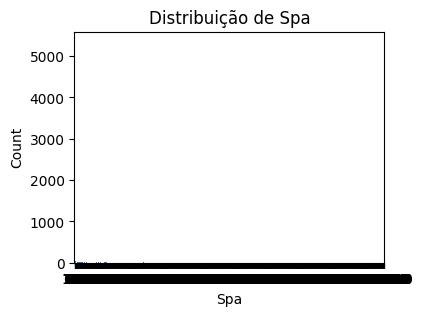

In [ ]:
# distribuição de frequência 'Spa'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='Spa')
plt.title('Distribuição de Spa')
plt.xlabel('Spa')
plt.ylabel('Count')
plt.show()

O padrão se mantém.

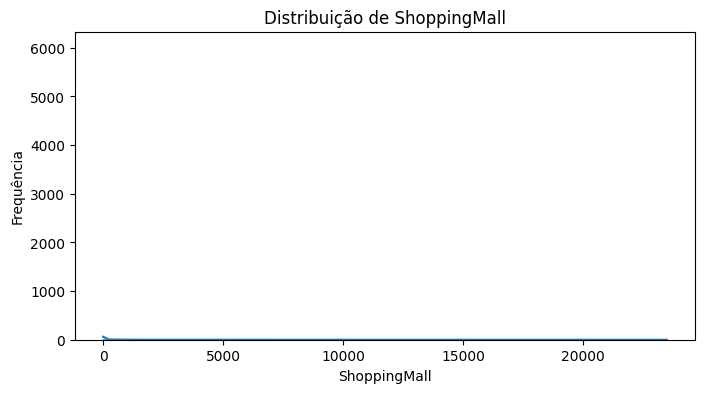

In [ ]:
# Distribuição de 'ShoppingMall' com histograma

plt.figure(figsize=(8, 4))
sns.histplot(data=df_train, x='ShoppingMall', kde=True)
plt.title('Distribuição de ShoppingMall')
plt.xlabel('ShoppingMall')
plt.ylabel('Frequência')
plt.show()

Number of passengers with 0 Spa spending: 5324
Number of passengers with non-zero Spa spending: 3186


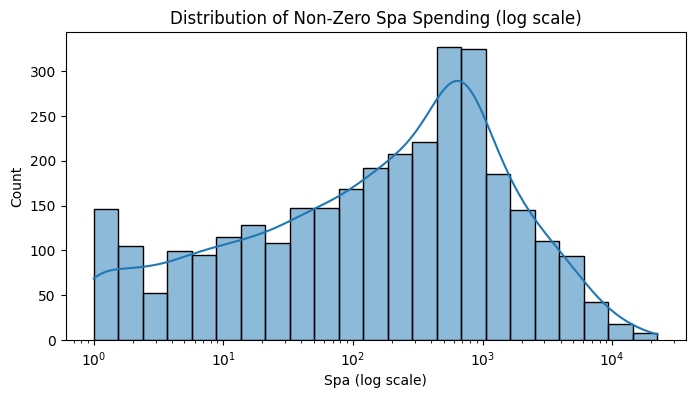

In [ ]:
zero_spa = df_train[df_train['Spa'] == 0]['Spa'].count()
non_zero_spa = df_train[df_train['Spa'] > 0]['Spa']

print(f"Number of passengers with 0 Spa spending: {zero_spa}")
print(f"Number of passengers with non-zero Spa spending: {non_zero_spa.count()}")


if non_zero_spa.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_spa, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero Spa Spending (log scale)')
    plt.xlabel('Spa (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero Spa spending to visualize.")

In [ ]:
# Calculando a mediana Spa com um groupby 'HomePlanet' e 'Destination'
median_spa_by_group = df_train.groupby(['HomePlanet', 'Destination'])['Spa'].median()

In [ ]:
# Imputando os dados
df_train['Spa'] = df_train.groupby(['HomePlanet', 'Destination'])['Spa'].transform(lambda x: x.fillna(x.median()))

Verificando a quantidade de dados faltantes em 'ShoppingMall' após imputação


In [ ]:
df_train['Spa'].isnull().sum()

np.int64(0)

Number of passengers with 0 Spa spending: 5484
Number of passengers with non-zero Spa spending: 3209


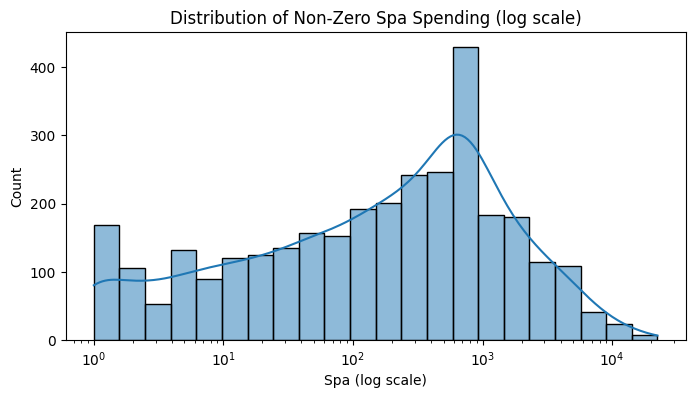

In [ ]:
# Distribuição de frequência após a imputação.

zero_spa = df_train[df_train['Spa'] == 0]['Spa'].count()
non_zero_spa = df_train[df_train['Spa'] > 0]['Spa']

print(f"Number of passengers with 0 Spa spending: {zero_spa}")
print(f"Number of passengers with non-zero Spa spending: {non_zero_spa.count()}")


if non_zero_spa.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_spa, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero Spa Spending (log scale)')
    plt.xlabel('Spa (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero Spa spending to visualize.")

Lembrar que o método logarítmico vai evidenciar (muito) as posições com maior proporção de gastos, dando a impressão de "puxar muito". As características das "spending_cols" ainda estão mantidas.

### Imputação de 'Spa' usando a Média Agrupada (teste)

Mean Spa by HomePlanet and Destination:


HomePlanet  Destination  
Earth       55 Cancri e       138.506241
            PSO J318.5-22      87.454670
            TRAPPIST-1e       156.620453
Europa      55 Cancri e       821.895034
            PSO J318.5-22    1188.947368
            TRAPPIST-1e       830.569331
Mars        55 Cancri e        92.818653
            PSO J318.5-22     118.040816
            TRAPPIST-1e       109.567568
Name: Spa, dtype: float64


Quantidade de dados faltantes em 'Spa' após imputação (Média):


np.int64(0)


Number of passengers with 0 Spa spending after mean imputation: 5484
Number of passengers with non-zero Spa spending after mean imputation: 3209


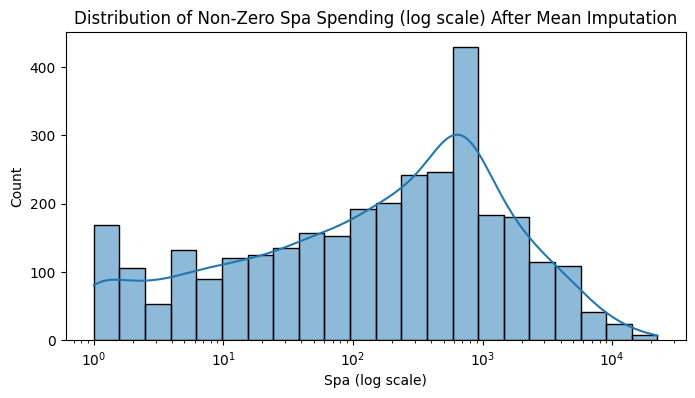

In [ ]:
# Criando uma cópia do dataframe para comparar as imputações
df_train_mean_imputed = df_train.copy()

# Calculando a média Spa com um groupby 'HomePlanet' e 'Destination'
mean_spa_by_group = df_train_mean_imputed.groupby(['HomePlanet', 'Destination'])['Spa'].mean()

print("Mean Spa by HomePlanet and Destination:")
display(mean_spa_by_group)

# Imputando os dados.
df_train_mean_imputed['Spa'] = df_train_mean_imputed.groupby(['HomePlanet', 'Destination'])['Spa'].transform(lambda x: x.fillna(x.mean()))

# Verificando a quantidade de dados faltantes em 'Spa' após imputação
print("\nQuantidade de dados faltantes em 'Spa' após imputação (Média):")
display(df_train_mean_imputed['Spa'].isnull().sum())

# Plotando o histograma em escala logarítmica após a imputação por média para visualizar a distribuição não-zero
zero_spa_mean_imputed = df_train_mean_imputed[df_train_mean_imputed['Spa'] == 0]['Spa'].count()
non_zero_spa_mean_imputed = df_train_mean_imputed[df_train_mean_imputed['Spa'] > 0]['Spa']

print(f"\nNumber of passengers with 0 Spa spending after mean imputation: {zero_spa_mean_imputed}")
print(f"Number of passengers with non-zero Spa spending after mean imputation: {non_zero_spa_mean_imputed.count()}")

if non_zero_spa_mean_imputed.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_spa_mean_imputed, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero Spa Spending (log scale) After Mean Imputation')
    plt.xlabel('Spa (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero Spa spending to visualize after mean imputation.")

A imputação com mediana mostrou-se mais fiel.

## VRDeck

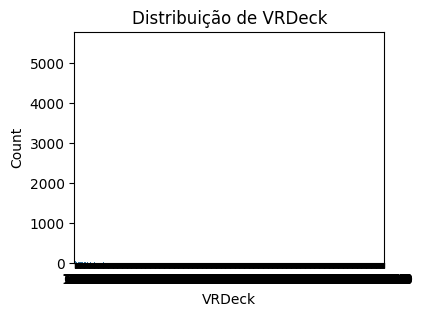

In [ ]:
# distribuição de frequência 'VRDeck'

plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='VRDeck')
plt.title('Distribuição de VRDeck')
plt.xlabel('VRDeck')
plt.ylabel('Count')
plt.show()

Number of passengers with 0 VRDeck spending: 5495
Number of passengers with non-zero VRDeck spending: 3010


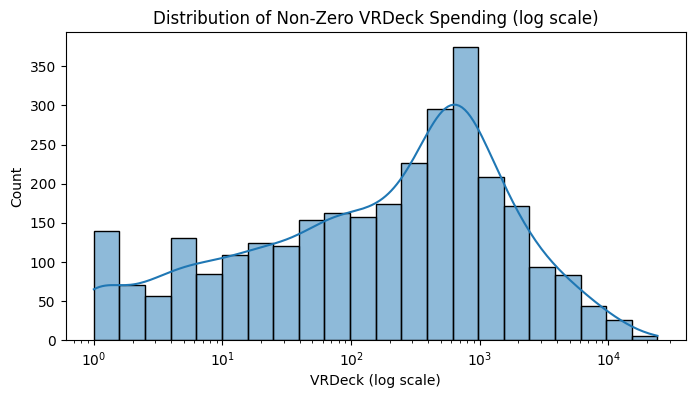

In [ ]:
zero_vrdeck = df_train[df_train['VRDeck'] == 0]['VRDeck'].count()
non_zero_vrdeck = df_train[df_train['VRDeck'] > 0]['VRDeck']

print(f"Number of passengers with 0 VRDeck spending: {zero_vrdeck}")
print(f"Number of passengers with non-zero VRDeck spending: {non_zero_vrdeck.count()}")


if non_zero_vrdeck.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_vrdeck, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero VRDeck Spending (log scale)')
    plt.xlabel('VRDeck (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero VRDeck spending to visualize.")

In [ ]:
# Calculando a mediana VRDeck com um groupby 'HomePlanet' e 'Destination'
median_vrdeck_by_group = df_train.groupby(['HomePlanet', 'Destination'])['VRDeck'].median()

In [ ]:
print("Median VRDeck by HomePlanet and Destination:")
display(median_vrdeck_by_group)

Median VRDeck by HomePlanet and Destination:


HomePlanet  Destination  
Earth       55 Cancri e      0.0
            PSO J318.5-22    0.0
            TRAPPIST-1e      0.0
Europa      55 Cancri e      0.0
            PSO J318.5-22    4.0
            TRAPPIST-1e      1.0
Mars        55 Cancri e      0.0
            PSO J318.5-22    0.0
            TRAPPIST-1e      0.0
Name: VRDeck, dtype: float64

In [ ]:
# Imputando os dados.
df_train['VRDeck'] = df_train.groupby(['HomePlanet', 'Destination'])['VRDeck'].transform(lambda x: x.fillna(x.median()))

Verificando a quantidade de dados faltantes em 'VRDeck' após imputação

In [ ]:
df_train['VRDeck'].isnull().sum()

np.int64(0)

Number of passengers with 0 VRDeck spending: 5665
Number of passengers with non-zero VRDeck spending: 3028


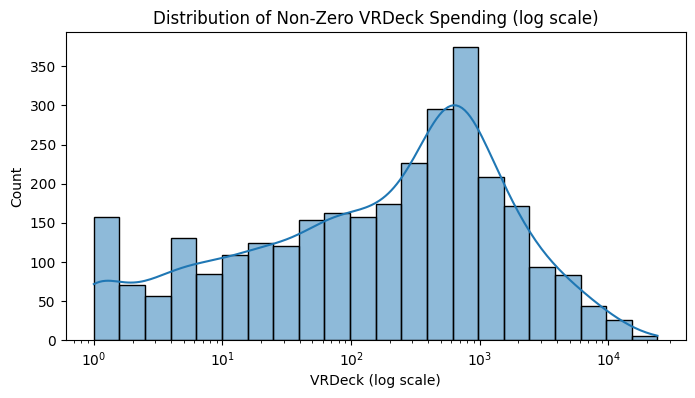

In [ ]:
# Distribuição após a imputação.

zero_vrdeck = df_train[df_train['VRDeck'] == 0]['VRDeck'].count()
non_zero_vrdeck = df_train[df_train['VRDeck'] > 0]['VRDeck']

print(f"Number of passengers with 0 VRDeck spending: {zero_vrdeck}")
print(f"Number of passengers with non-zero VRDeck spending: {non_zero_vrdeck.count()}")


if non_zero_vrdeck.count() > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_vrdeck, kde=True, log_scale=True)
    plt.title('Distribution of Non-Zero VRDeck Spending (log scale)')
    plt.xlabel('VRDeck (log scale)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No non-zero VRDeck spending to visualize.")

## Name

Geralmente o nome não é um fator preditivo forte. Portanto, optaremos somente por substituir as células NaN com um placeholder 'desconhecido'.

In [ ]:
# Preenchendo valores faltantes em 'Name' com 'Desconhecido'
df_train['Name'] = df_train['Name'].fillna('Desconhecido')
df_train['Name'].isnull().sum()

np.int64(0)

# Imputação dos dados faltantes em df_test com base nos dados de df_train

## HomePlanet

In [ ]:
# Imputar HomePlanet em df_test usando a moda de df_train
mode_homeplanet_train = df_train['HomePlanet'].mode()[0]
df_test['HomePlanet'] = df_test['HomePlanet'].fillna(mode_homeplanet_train)

# Verificar dados faltantes em HomePlanet após imputação
print("Quantidade de dados faltantes em 'HomePlanet' em df_test após imputação:")
display(df_test['HomePlanet'].isnull().sum())

Quantidade de dados faltantes em 'HomePlanet' em df_test após imputação:


np.int64(0)

## CryoSleep

In [ ]:
# Imputar CryoSleep em df_test usando a moda de df_train

# Converter para booleano antes de imputar, lidando com NaNs
df_test['CryoSleep'] = df_test['CryoSleep'].astype(bool)

# Calcular a moda no df_train (já feito anteriormente, apenas recuperando o valor se necessário, ou recalculando para clareza)
mode_cryosleep_train = df_train['CryoSleep'].mode()[0]

# Imputar os valores faltantes em df_test
df_test['CryoSleep'] = df_test['CryoSleep'].fillna(mode_cryosleep_train)

# Verificar dados faltantes em CryoSleep após imputação
print("Quantidade de dados faltantes em 'CryoSleep' em df_test após imputação:")
display(df_test['CryoSleep'].isnull().sum())

Quantidade de dados faltantes em 'CryoSleep' em df_test após imputação:


np.int64(0)

### Verificando dados faltantes em df_test após a imputação

In [ ]:
print("Quantidade total de dados faltantes em df_test após a imputação:")
display(df_test.isnull().sum())

Quantidade total de dados faltantes em df_test após a imputação:


,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,100
Destination,92
Age,91
VIP,93
RoomService,82
FoodCourt,106
ShoppingMall,98


## Cabin

In [ ]:
# Separando a coluna 'Cabin' em 'Cabin_Deck', 'Cabin_Num' e 'Cabin_Side' no df_test
df_test[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_test['Cabin'].str.split('/', expand=True)

# Imputar Cabin_Deck em df_test usando a moda de df_train
mode_cabin_deck_train = df_train['Cabin_Deck'].mode()[0]
df_test['Cabin_Deck'] = df_test['Cabin_Deck'].fillna(mode_cabin_deck_train)

# Imputar Cabin_Side em df_test usando a moda de df_train
mode_cabin_side_train = df_train['Cabin_Side'].mode()[0]
df_test['Cabin_Side'] = df_test['Cabin_Side'].fillna(mode_cabin_side_train)

# Convertendo 'Cabin_Num' para float (necessário para calcular a mediana/média)
df_test['Cabin_Num'] = pd.to_numeric(df_test['Cabin_Num'], errors='coerce')

# Imputando valores faltantes em 'Cabin_Num' com a mediana por 'Cabin_Deck' calculada no df_train
# Usamos o mapa de medianas calculado anteriormente no df_train
median_cabin_num_by_deck_train = df_train.groupby('Cabin_Deck')['Cabin_Num'].median()

# Função para aplicar a imputação baseada no deck
def impute_cabin_num(row):
    if pd.isna(row['Cabin_Num']):
        deck = row['Cabin_Deck']
        # Usar .get() com um valor padrão (como a mediana geral do df_train ou 0) caso o deck não exista no mapa
        return median_cabin_num_by_deck_train.get(deck, df_train['Cabin_Num'].median())
    return row['Cabin_Num']

df_test['Cabin_Num'] = df_test.apply(impute_cabin_num, axis=1)

# Ensure Cabin_Num is integer type for the next step
df_test['Cabin_Num'] = df_test['Cabin_Num'].astype(int)

# Verify the imputation
print("Quantidade de dados faltantes em 'Cabin_Deck' em df_test após imputação:")
display(df_test['Cabin_Deck'].isnull().sum())

print("\nQuantidade de dados faltantes em 'Cabin_Side' em df_test após imputação:")
display(df_test['Cabin_Side'].isnull().sum())

print("\nQuantidade de dados faltantes em 'Cabin_Num' em df_test após imputação:")
display(df_test['Cabin_Num'].isnull().sum())

Quantidade de dados faltantes em 'Cabin_Deck' em df_test após imputação:


np.int64(0)


Quantidade de dados faltantes em 'Cabin_Side' em df_test após imputação:


np.int64(0)


Quantidade de dados faltantes em 'Cabin_Num' em df_test após imputação:


np.int64(0)

In [ ]:
# Separando a coluna 'Cabin' em 'Cabin_Deck', 'Cabin_Num' e 'Cabin_Side' no df_test
df_test[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_test['Cabin'].str.split('/', expand=True)

display(df_test[['Cabin', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side']].head())

,Cabin,Cabin_Deck,Cabin_Num,Cabin_Side
0,G/3/S,G,3,S
1,F/4/S,F,4,S
2,C/0/S,C,0,S
3,C/1/S,C,1,S
4,F/5/S,F,5,S


### Cabin_Deck e Cabin_Side

In [ ]:
# Imputar Cabin_Deck em df_test usando a moda de df_train
mode_cabin_deck_train = df_train['Cabin_Deck'].mode()[0]
df_test['Cabin_Deck'] = df_test['Cabin_Deck'].fillna(mode_cabin_deck_train)

# Imputar Cabin_Side em df_test usando a moda de df_train
mode_cabin_side_train = df_train['Cabin_Side'].mode()[0]
df_test['Cabin_Side'] = df_test['Cabin_Side'].fillna(mode_cabin_side_train)


# Verificar dados faltantes
print("Quantidade de dados faltantes em 'Cabin_Deck' em df_test após imputação:")
display(df_test['Cabin_Deck'].isnull().sum())

print("\nQuantidade de dados faltantes em 'Cabin_Side' em df_test após imputação:")
display(df_test['Cabin_Side'].isnull().sum())

Quantidade de dados faltantes em 'Cabin_Deck' em df_test após imputação:


np.int64(0)


Quantidade de dados faltantes em 'Cabin_Side' em df_test após imputação:


np.int64(0)

### Cabin_Num

In [ ]:
# Convertendo 'Cabin_Num' para float (necessário para calcular a mediana/média)
df_test['Cabin_Num'] = pd.to_numeric(df_test['Cabin_Num'], errors='coerce')

# Imputando valores faltantes em 'Cabin_Num' com a mediana por 'Cabin_Deck' calculada no df_train
# Usamos o mapa de medianas calculado anteriormente no df_train
median_cabin_num_by_deck_train = df_train.groupby('Cabin_Deck')['Cabin_Num'].median()

# Função para aplicar a imputação baseada no deck
def impute_cabin_num(row):
    if pd.isna(row['Cabin_Num']):
        deck = row['Cabin_Deck']
        # Usar .get() com um valor padrão (como a mediana geral do df_train ou 0) caso o deck não exista no mapa
        return median_cabin_num_by_deck_train.get(deck, df_train['Cabin_Num'].median())
    return row['Cabin_Num']

df_test['Cabin_Num'] = df_test.apply(impute_cabin_num, axis=1)


# Verificando a quantidade de dados faltantes após a imputação
print("\nQuantidade de dados faltantes em 'Cabin_Num' em df_test após imputação:")
display(df_test['Cabin_Num'].isnull().sum())


Quantidade de dados faltantes em 'Cabin_Num' em df_test após imputação:


np.int64(0)

In [ ]:
# Reconstruindo a coluna 'Cabin' em df_test
df_test['Cabin'] = df_test.apply(
    lambda row: f"{row['Cabin_Deck']}/{int(row['Cabin_Num'])}/{row['Cabin_Side']}" if pd.isna(row['Cabin']) else row['Cabin'],
    axis=1
)

# Verificando a quantidade de dados faltantes em 'Cabin' em df_test após a atualização
print("Quantidade de dados faltantes em 'Cabin' em df_test após atualização:")
display(df_test['Cabin'].isnull().sum())

Quantidade de dados faltantes em 'Cabin' em df_test após atualização:


np.int64(0)

## Destination

In [ ]:
# Imputar Destination em df_test usando a moda de df_train
mode_destination_train = df_train['Destination'].mode()[0]
df_test['Destination'] = df_test['Destination'].fillna(mode_destination_train)

# Verificar dados faltantes em Destination após imputação
print("Quantidade de dados faltantes em 'Destination' em df_test após imputação:")
display(df_test['Destination'].isnull().sum())

Quantidade de dados faltantes em 'Destination' em df_test após imputação:


np.int64(0)

## Age

In [ ]:
# Imputar Age em df_test usando a média agrupada por HomePlanet e a média geral de df_train

# Calculando a média de Age por HomePlanet no df_train
mean_age_by_homeplanet_train = df_train.groupby('HomePlanet')['Age'].mean()

# Imputando valores faltantes em 'Age' no df_test com a média por 'HomePlanet' calculada no df_train
df_test['Age'] = df_test.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(mean_age_by_homeplanet_train.get(x.name, df_train['Age'].mean())))

# Preencher quaisquer NaNs remanescentes com a média geral de Age do df_train
df_test['Age'].fillna(df_train['Age'].mean(), inplace=True)

# Convertendo a coluna 'Age' para inteiro após a imputação
df_test['Age'] = df_test['Age'].astype(int)


# Verificar dados faltantes em Age após imputação
print("Quantidade de dados faltantes em 'Age' em df_test após imputação:")
display(df_test['Age'].isnull().sum())

Quantidade de dados faltantes em 'Age' em df_test após imputação:


/tmp/ipython-input-3321379697.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Age'].fillna(df_train['Age'].mean(), inplace=True)


np.int64(0)

## VIP

In [ ]:
# Imputar VIP em df_test usando a moda de df_train agrupada por HomePlanet e Destination

# Calcular a moda no df_train agrupada por HomePlanet e Destination
mode_vip_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['VIP'].agg(lambda x: x.mode()[0] if not x.mode().empty else False)

# Função para aplicar a imputação baseada no grupo
def impute_vip(row):
    if pd.isna(row['VIP']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como False ou a moda geral do df_train) caso o grupo não exista no mapa
        return mode_vip_train_grouped.get(group_key, df_train['VIP'].mode()[0] if not df_train['VIP'].mode().empty else False)
    return row['VIP']

# Aplicar a função para imputar valores faltantes em 'VIP' no df_test
df_test['VIP'] = df_test.apply(impute_vip, axis=1)


# Verificar dados faltantes em VIP após imputação
print("Quantidade de dados faltantes em 'VIP' em df_test após imputação:")
display(df_test['VIP'].isnull().sum())

Quantidade de dados faltantes em 'VIP' em df_test após imputação:


np.int64(0)

## RoomService

In [ ]:
# Imputar RoomService em df_test usando a mediana de df_train agrupada por HomePlanet e Destination

# Calculando a mediana RoomService no df_train agrupada por HomePlanet e Destination
median_roomservice_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['RoomService'].median()

# Função para aplicar a imputação baseada no grupo
def impute_roomservice(row):
    if pd.isna(row['RoomService']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como 0 ou a mediana geral do df_train) caso o grupo não exista no mapa
        return median_roomservice_train_grouped.get(group_key, df_train['RoomService'].median())
    return row['RoomService']

# Aplicar a função para imputar valores faltantes em 'RoomService' no df_test
df_test['RoomService'] = df_test.apply(impute_roomservice, axis=1)


# Verificar dados faltantes em RoomService após imputação
print("Quantidade de dados faltantes em 'RoomService' em df_test após imputação:")
display(df_test['RoomService'].isnull().sum())

Quantidade de dados faltantes em 'RoomService' em df_test após imputação:


np.int64(0)

## FoodCourt

In [ ]:
# Imputar FoodCourt em df_test usando a mediana de df_train agrupada por HomePlanet e Destination

# Calculando a mediana FoodCourt no df_train agrupada por HomePlanet e Destination
median_foodcourt_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['FoodCourt'].median()

# Função para aplicar a imputação baseada no grupo
def impute_foodcourt(row):
    if pd.isna(row['FoodCourt']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como 0 ou a mediana geral do df_train) caso o grupo não exista no mapa
        return median_foodcourt_train_grouped.get(group_key, df_train['FoodCourt'].median())
    return row['FoodCourt']

# Aplicar a função para imputar valores faltantes em 'FoodCourt' no df_test
df_test['FoodCourt'] = df_test.apply(impute_foodcourt, axis=1)


# Verificar dados faltantes em FoodCourt após imputação
print("Quantidade de dados faltantes em 'FoodCourt' em df_test após imputação:")
display(df_test['FoodCourt'].isnull().sum())

Quantidade de dados faltantes em 'FoodCourt' em df_test após imputação:


np.int64(0)

## ShoppingMall

In [ ]:
# Imputar ShoppingMall em df_test usando a mediana de df_train agrupada por HomePlanet e Destination

# Calculando a mediana ShoppingMall no df_train agrupada por HomePlanet e Destination
median_shoppingmall_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['ShoppingMall'].median()

# Função para aplicar a imputação baseada no grupo
def impute_shoppingmall(row):
    if pd.isna(row['ShoppingMall']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como 0 ou a mediana geral do df_train) caso o grupo não exista no mapa
        return median_shoppingmall_train_grouped.get(group_key, df_train['ShoppingMall'].median())
    return row['ShoppingMall']

# Aplicar a função para imputar valores faltantes em 'ShoppingMall' no df_test
df_test['ShoppingMall'] = df_test.apply(impute_shoppingmall, axis=1)


# Verificar dados faltantes em ShoppingMall após imputação
print("Quantidade de dados faltantes em 'ShoppingMall' em df_test após imputação:")
display(df_test['ShoppingMall'].isnull().sum())

Quantidade de dados faltantes em 'ShoppingMall' em df_test após imputação:


np.int64(0)

## Spa

In [ ]:
# Imputar Spa em df_test usando a mediana de df_train agrupada por HomePlanet e Destination

# Calculando a mediana Spa no df_train agrupada por HomePlanet e Destination
median_spa_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['Spa'].median()

# Função para aplicar a imputação baseada no grupo
def impute_spa(row):
    if pd.isna(row['Spa']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como 0 ou a mediana geral do df_train) caso o grupo não exista no mapa
        return median_spa_train_grouped.get(group_key, df_train['Spa'].median())
    return row['Spa']

# Aplicar a função para imputar valores faltantes em 'Spa' no df_test
df_test['Spa'] = df_test.apply(impute_spa, axis=1)


# Verificar dados faltantes em Spa após imputação
print("Quantidade de dados faltantes em 'Spa' em df_test após imputação:")
display(df_test['Spa'].isnull().sum())

Quantidade de dados faltantes em 'Spa' em df_test após imputação:


np.int64(0)

## VRDeck

In [ ]:
# Imputar VRDeck em df_test usando a mediana de df_train agrupada por HomePlanet e Destination

# Calculando a mediana VRDeck no df_train agrupada por HomePlanet e Destination
median_vrdeck_train_grouped = df_train.groupby(['HomePlanet', 'Destination'])['VRDeck'].median()

# Função para aplicar a imputação baseada no grupo
def impute_vrdeck(row):
    if pd.isna(row['VRDeck']):
        group_key = (row['HomePlanet'], row['Destination'])
        # Usar .get() com um valor padrão (como 0 ou a mediana geral do df_train) caso o grupo não exista no mapa
        return median_vrdeck_train_grouped.get(group_key, df_train['VRDeck'].median())
    return row['VRDeck']

# Aplicar a função para imputar valores faltantes em 'VRDeck' no df_test
df_test['VRDeck'] = df_test.apply(impute_vrdeck, axis=1)


# Verificar dados faltantes em VRDeck após imputação
print("Quantidade de dados faltantes em 'VRDeck' em df_test após imputação:")
display(df_test['VRDeck'].isnull().sum())

Quantidade de dados faltantes em 'VRDeck' em df_test após imputação:


np.int64(0)

## Name

In [ ]:
# Preenchendo valores faltantes em 'Name' com 'Desconhecido' no df_test
df_test['Name'] = df_test['Name'].fillna('Desconhecido')

# Verificando a quantidade de dados faltantes em 'Name' em df_test após a imputação
print("Quantidade de dados faltantes em 'Name' em df_test após imputação:")
display(df_test['Name'].isnull().sum())

Quantidade de dados faltantes em 'Name' em df_test após imputação:


np.int64(0)

# Introdução ao modelo (Árvore de Decisão)

Passageiros sem gastos: 3595
Passageiros com gastos: 5098


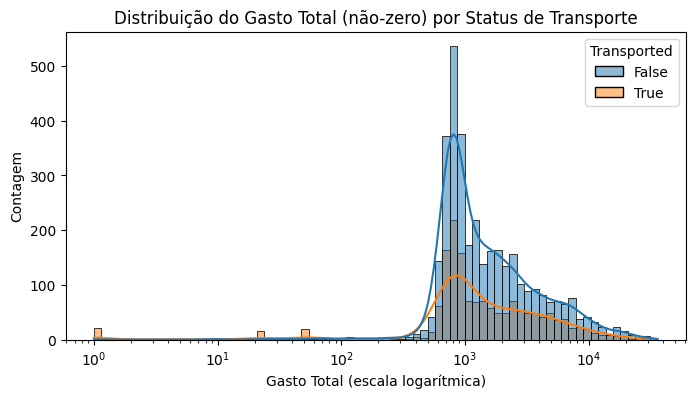

In [ ]:
# Criando uma nova coluna que represente o gasto total
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_train['TotalSpending'] = df_train[spending_cols].sum(axis=1)

# Separando as colunas que tiveram gastos e que não tiveram gastos. Isso se faz necessário porque a visualização de spending_cols,
# como explorado anteriormente segue um pardrão logarítmico.

zero_total_spending = df_train[df_train['TotalSpending'] == 0]['TotalSpending'].count()
non_zero_total_spending = df_train[df_train['TotalSpending'] > 0]

print(f"Passageiros sem gastos: {zero_total_spending}")
print(f"Passageiros com gastos: {non_zero_total_spending.shape[0]}")

# Visualização dos passageiros com gasto (log)
if non_zero_total_spending.shape[0] > 0: # Verificação para se enquadrar na condição de domínio
    plt.figure(figsize=(8, 4))
    sns.histplot(data=non_zero_total_spending, x='TotalSpending', hue='Transported', kde=True, log_scale=True)
    plt.title('Distribuição do Gasto Total (não-zero) por Status de Transporte')
    plt.xlabel('Gasto Total (escala logarítmica)')
    plt.ylabel('Contagem')
    plt.show()
else:
    print("No non-zero Total Spending to visualize.")

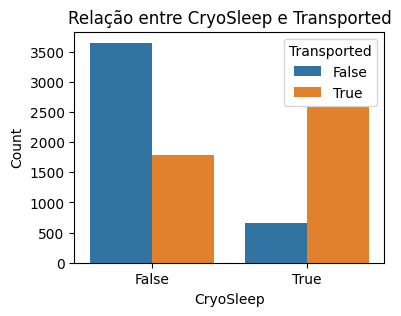

In [ ]:
# Análise da relação entre 'CryoSleep' e 'Transported'
plt.figure(figsize=(4, 3))
sns.countplot(data=df_train, x='CryoSleep', hue='Transported')
plt.title('Relação entre CryoSleep e Transported')
plt.xlabel('CryoSleep')
plt.ylabel('Count')
plt.show()

O gráfico de contagem de 'CryoSleep' demonstra que uma proporção muito maior de passageiros em sono criogênico (True) foi transportada em comparação com aqueles que não estavam em sono criogênico (False).

Passageiros em sono criogênico não teriam gastos em serviços a bordo. Portanto, faz todo o sentido que eles tenham gasto total zero e uma alta probabilidade de serem transportados

Obs. Sem o LabelEnconding, chegamos em uma acurácia de ~0,70

## Começando a trabalhar no modelo

### Definindo as variáveis para o modelo

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder -> importante para trazer significado numérico às colunas categóricas. Assim como fazíamos com dummies, por exemplo (não é a mesma lógica)
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# Atribuindo as variáveis (+ categóricas e TotalSpending)
features = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side',
            'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt',
            'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending']
target = 'Transported'

# Definindo o conjunto preditor e a variável predita
X = df_train[features]
y = df_train[target]

### Variáveis categóricas (LabelEnconding)

In [ ]:
# Trabalhando em cima das variáveis categóricas (com o LabelEnconding)
categorical_features = ['HomePlanet', 'Cabin_Deck', 'Cabin_Side', 'Destination']

for col in categorical_features:
    if col in X.columns:
        le = LabelEncoder()

        # Fazer um fitting das bases para assegurar que todas as variáveis estejam sendo abordadas
        combined_series = pd.concat([X[col], df_test[col]], axis=0).astype(str).unique()
        le.fit(combined_series)
        X[col] = le.transform(X[col].astype(str))

        # Fazendo para df_test para garantir consistência
        df_test[col] = le.transform(df_test[col].astype(str))

/tmp/ipython-input-215440764.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.transform(X[col].astype(str))
/tmp/ipython-input-215440764.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.transform(X[col].astype(str))
/tmp/ipython-input-215440764.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

Ao aplicar label encoding, a etapa le.fit() é crucial porque “ensina” o codificador a reconhecer todas as categorias que existirão naquela coluna, construindo o mapeamento interno de rótulos para inteiros que será usado depois na transformação. Para garantir que nenhuma categoria presente no conjunto de teste se torne “desconhecida” na hora de transformar, é comum combinar temporariamente os valores da coluna de treino e de teste com pd.concat([X[col], df_test[col]], axis=0), padronizar os tipos com .astype(str) e extrair a lista de categorias únicas com .unique(), de modo que o ajuste do encoder considere o universo completo de valores que podem aparecer em ambos os conjuntos. Em seguida, le.fit() sobre essa lista de categorias únicas cria o mapeamento interno, por exemplo, ‘Earth’ → 0, ‘Europa’ → 1, ‘Mars’ → 2, deixando o encoder pronto para transformar dados consistemente. Na fase de transformação, le.transform(X[col].astype(str)) aplica o mapeamento aprendido aos valores originais do treino e os converte em números, que então substituem o texto na própria coluna X[col] para manter o DataFrame coerente para modelagem. O mesmo processo é replicado para o conjunto de teste com df_test[col] = le.transform(df_test[col].astype(str)), sempre reutilizando exatamente o mapeamento aprendido no ajuste, o que assegura que a mesma categoria receba o mesmo inteiro em treino e teste. Em síntese, ajusta-se o encoder sobre todas as categorias possíveis vindas do treino e do teste e, depois, transforma-se cada conjunto separadamente, preservando a consistência e evitando erros de categorias não vistas durante a transformação do conjunto de teste.

### Treinamento

In [ ]:
# Calculando 'TotalSpending', a que coluna que adicionamos, para df_test
df_test['TotalSpending'] = df_test[spending_cols].sum(axis=1)

# Treino / teste (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify=y porque [explicar]

# Declarando o modelo
model_arvore = DecisionTreeClassifier(random_state=42)

# Treinando o modelo com os dados de TREINO
model_arvore.fit(X_train, y_train)

# Verificando a eficácia do modelo
y_pred_val = model_arvore.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)
print(f"Acurácia: {acc_val:.4f}")
print("\n Relatório:")
print(classification_report(y_val, y_pred_val))

Acurácia: 0.7453

 Relatório:
              precision    recall  f1-score   support

       False       0.74      0.75      0.74       863
        True       0.75      0.74      0.75       876

    accuracy                           0.75      1739
   macro avg       0.75      0.75      0.75      1739
weighted avg       0.75      0.75      0.75      1739



### Predição

In [ ]:
# Predição no df_test
df_test_predicao = df_test[features].astype(X.dtypes) # Para assegurar que estamos trabalhando com matching

df_test['Transported_Predicted'] = model_arvore.predict(df_test_predicao)
df_test[['PassengerId', 'Transported_Predicted']].head()

,PassengerId,Transported_Predicted
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## Visualização da árvore

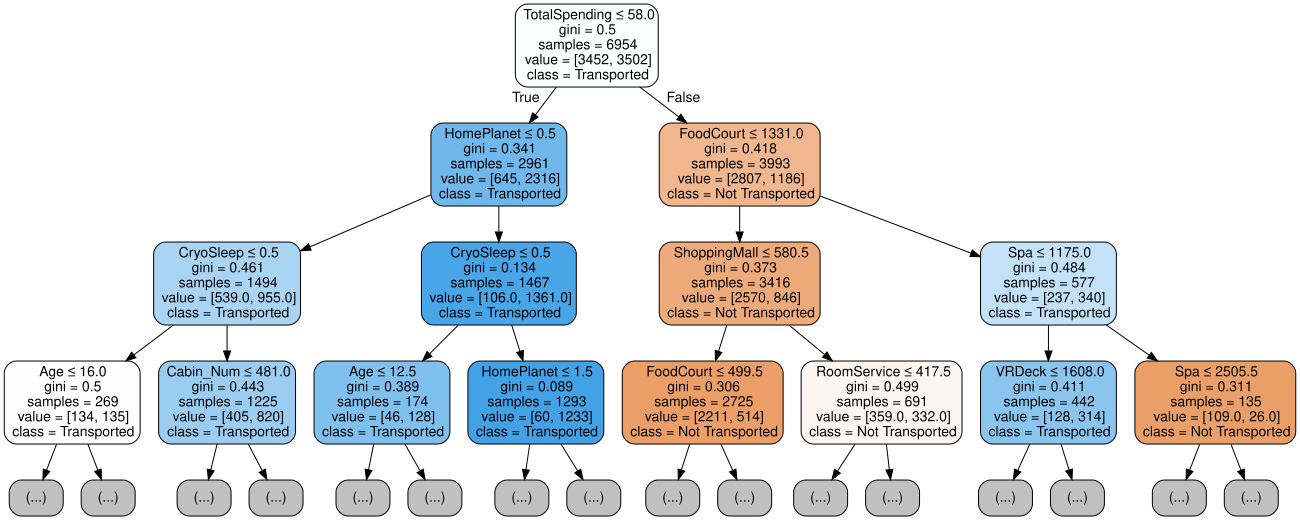

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

model_to_visualize = model_arvore
feature_names = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side',
            'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt',
            'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending']

dot_data = export_graphviz(
    model_arvore,
    out_file=None,
    feature_names=feature_names,
    class_names=['Not Transported', 'Transported'], # 0 - não transportado; 1 - transportado
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3 # Limitando a profundidade para melhor visualização
)

grafico_arvore = graphviz.Source(dot_data)
display(grafico_arvore)

## Atribuição em df_sub

In [ ]:
# Atribuição em df_sub
df_sub['Transported'] = df_test['Transported_Predicted']
df_sub.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


# Códigos (tentativas) - EXTRA

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Define features (X) and target (y) for df_train
# Exclude 'PassengerId', 'Name', and the original 'Cabin' as we have the split parts
features = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side',
            'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt',
            'ShoppingMall', 'Spa', 'VRDeck']
target = 'Transported'

X_train = df_train[features]
y_train = df_train[target]

# Identify categorical and numerical features
categorical_features = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Side', 'Destination', 'VIP']
numerical_features = ['Cabin_Num', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Create a column transformer to apply one-hot encoding to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('passthrough', 'passthrough', numerical_features)
    ])

# Create a Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Create a pipeline that first preprocesses the data and then trains the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', dt_model)])

# Train the model
pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


The Decision Tree model has been trained using the specified features from `df_train`. The next step is to use this model to make predictions on `df_test`.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_val_score
)

# Usa StratifiedGroupKFold se existir (sklearn >=1.3), senão cai para StratifiedKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_SGKF = True
except Exception:
    HAS_SGKF = False

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint, loguniform

RANDOM_STATE = 42

def get_col(df, name_lower):
    for c in df.columns:
        if c.lower() == name_lower.lower():
            return c
    return None

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    col_cabin = get_col(df, 'Cabin')
    col_passenger = get_col(df, 'PassengerId')
    col_age = get_col(df, 'Age')
    col_cryosleep = get_col(df, 'CryoSleep')
    col_name = get_col(df, 'Name')
    col_target = get_col(df, 'Transported') or get_col(df, 'transported')

    # Converte gastos p/ numérico e trata
    spend_aliases = {'roomservice', 'foodcourt', 'shoppingmall', 'spa', 'vrdeck'}
    spend_cols = [c for c in df.columns if c.lower() in spend_aliases]
    for c in spend_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df.loc[df[c] < 0, c] = 0  # sem gastos negativos

    # Zerar gastos se CryoSleep=True
    if col_cryosleep and spend_cols:
        # Ensure CryoSleep is treated as boolean/string for this check
        # Use .loc with a boolean mask for safer assignment
        df.loc[df[col_cryosleep].astype(str).str.lower() == 'true', spend_cols] = 0


    # Winsoriza extremos (99º pct) e cria totais
    if spend_cols:
        for c in spend_cols:
            p99 = df[c].quantile(0.99)
            df[c] = np.minimum(df[c], p99)
        df['TotalSpending'] = df[spend_cols].sum(axis=1)
        df['LogTotalSpending'] = np.log1p(df['TotalSpending'])
        df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)

    # Cabin -> Deck / CabinNum / Side
    if col_cabin:
        parts = df[col_cabin].astype('string').str.split('/', expand=True)
        df['Deck'] = parts[0]
        df['CabinNum'] = pd.to_numeric(parts[1], errors='coerce')
        df['Side'] = parts[2]
        df['HasCabinNum'] = (~parts[1].isna()).astype(int)

    # PassengerId -> GroupId / GroupSize / IsAlone
    if col_passenger:
        df['GroupId'] = df[col_passenger].astype('string').str.split('_').str[0]
        # Calculate GroupSize after creating GroupId
        group_sizes = df.groupby('GroupId')[col_passenger].transform('count')
        df['GroupSize'] = group_sizes
        df['IsAlone'] = (df['GroupSize'] == 1).astype(int)


    # Age -> IsMinor + imputação por grupo (antes do imputer final)
    if col_age:
        df[col_age] = pd.to_numeric(df[col_age], errors='coerce')
        if 'GroupId' in df.columns:
            # Calculate group median on non-null Age values
            # Use transform with fillna for correct group-wise imputation
            df[col_age] = df.groupby('GroupId')[col_age].transform(lambda x: x.fillna(x.median()))
        df['IsMinor'] = (df[col_age] < 18).astype('float')

    # Remover textos pouco úteis
    drop_cols = []
    if col_name: drop_cols.append(col_name)
    if col_cabin: drop_cols.append(col_cabin)
    # Keep PassengerId for potential StratifiedGroupKFold
    # if col_passenger: drop_cols.append(col_passenger)
    df = df.drop(columns=drop_cols, errors='ignore')

    # Garante alvo binário int
    if col_target is not None and col_target in df.columns and df[col_target].dtype == bool:
        df[col_target] = df[col_target].astype(int)

    return df

def prepare_xy(df: pd.DataFrame):
    target_col = get_col(df, 'Transported') or get_col(df, 'transported')

    # Define the list of features that will be used by the preprocessor
    # Ensure this list is consistent with the engineered features
    feature_cols = [
        'HomePlanet', 'CryoSleep', 'Deck', 'Side', 'Destination', 'VIP',
        'CabinNum', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
        'TotalSpending', 'LogTotalSpending', 'GroupSize', 'IsAlone', 'HasCabinNum', 'IsMinor'
    ]
     # Add PassengerId/GroupId if present and needed for CV groups, but don't include in X for model training
    id_cols = []
    col_passenger = get_col(df, 'PassengerId')
    if col_passenger and col_passenger in df.columns:
        id_cols.append(col_passenger)
    if 'GroupId' in df.columns:
         id_cols.append('GroupId')

    # Filter feature_cols to include only those present in the dataframe
    features_in_df = [col for col in feature_cols if col in df.columns]

    if target_col is None or target_col not in df.columns:
        # If target column is not in df, assume it's the test set
        # Select only the defined features and ensure order
        X = df[features_in_df].copy()
        y = None # No target for test set
    else:
        y = df[target_col].astype(int)
         # Select only the defined features and ensure order
        X = df[features_in_df].copy()

    # Return X and y, and also the id columns if they exist for group CV
    if id_cols:
        return X, y, df[id_cols]
    else:
        return X, y, None # Return None for groups if no id_cols


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    # Define the lists of numerical and categorical features explicitly
    # These lists should match the columns selected in prepare_xy
    numerical_cols = ['CabinNum', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'LogTotalSpending', 'GroupSize', 'IsMinor']
    categorical_cols = ['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'Destination', 'VIP', 'IsAlone', 'HasCabinNum']

    # Filter columns to include only those present in X
    # Ensure numerical and categorical columns are correctly identified from the input X
    numeric_cols_present = [col for col in numerical_cols if col in X.columns]
    categorical_cols_present = [col for col in categorical_cols if col in X.columns]


    num_tf = SimpleImputer(strategy='median')
    cat_tf = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Create the ColumnTransformer, applying transformers only to the present columns
    # Use passthrough for any columns not explicitly listed (e.g., PassengerId if kept)
    return ColumnTransformer(
        transformers=[
            ('num', num_tf, numeric_cols_present),
            ('cat', cat_tf, categorical_cols_present)
        ],
        remainder='passthrough' # Keep any other columns (like PassengerId)
    )

def make_cv(y, groups):
    if HAS_SGKF and groups is not None and len(np.unique(groups)) > 1: # Check if groups are meaningful
        print("Usando StratifiedGroupKFold")
        return StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    print("Usando StratifiedKFold")
    return StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_decision_tree(X, y, preprocessor, groups=None):
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])

    param_distributions = {
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__splitter': ['best', 'random'],
        'clf__max_depth': randint(4, 25),
        'clf__min_samples_split': randint(2, 50),
        'clf__min_samples_leaf': randint(1, 20),
        'clf__max_features': [None, 'sqrt', 'log2', 0.4, 0.6, 0.8],
        'clf__max_leaf_nodes': [None, 32, 64, 128, 256, 512],
        'clf__min_impurity_decrease': loguniform(1e-7, 1e-3),
        'clf__ccp_alpha': [0.0] + list(np.logspace(-5, -3, 7)),
        'clf__class_weight': [None, 'balanced'],
    }

    cv = make_cv(y, groups)
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=80,              # aumente para 120 se tiver tempo
        scoring='accuracy',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    # Pass groups to fit if using StratifiedGroupKFold
    fit_params = {}
    if HAS_SGKF and groups is not None and len(np.unique(groups)) > 1:
         fit_params['groups'] = groups

    search.fit(X, y, **fit_params)

    return search

def eval_cv(pipe, X, y, groups=None):
    cv = make_cv(y, groups)
    # Pass groups to cross_val_score if using StratifiedGroupKFold
    cv_params = {}
    if HAS_SGKF and groups is not None and len(np.unique(groups)) > 1:
        cv_params['groups'] = groups

    scores = cross_val_score(
        pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1,
        **cv_params
    )
    return scores.mean(), scores.std()

# ===================== EXECUÇÃO =====================
# Apply feature engineering to train and test sets
df_train_fe = engineer_features(df_train)
df_test_fe = engineer_features(df_test) # Apply to df_test as well

# Prepare data for modeling
X_train, y_train, groups_train_df = prepare_xy(df_train_fe)
X_test, y_test, groups_test_df = prepare_xy(df_test_fe) # y_test will be None

# Get groups series from the dataframe
groups_train = groups_train_df['GroupId'] if groups_train_df is not None and 'GroupId' in groups_train_df.columns else None
groups_test = groups_test_df['GroupId'] if groups_test_df is not None and 'GroupId' in groups_test_df.columns else None


preprocessor = build_preprocessor(X_train) # Build preprocessor on training data


# Baseline (árvore "sensata" antes do tuning)
baseline = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        # max_features=0.6, # Removed as it can interact strangely with OHE
        class_weight='balanced',
        # ccp_alpha=1e-4, # Removed for baseline simplicity
        random_state=RANDOM_STATE
    ))
])
base_mean, base_std = eval_cv(baseline, X_train, y_train, groups_train)
print(f'Baseline DecisionTree acc={base_mean:.4f} (+/- {base_std:.4f})')

# Tuning
search = tune_decision_tree(X_train, y_train, preprocessor, groups_train)
print('Melhor acc (CV):', round(search.best_score_, 4))
print('Melhores params:', search.best_params_)

best_pipe = search.best_estimator_
final_mean, final_std = eval_cv(best_pipe, X_train, y_train, groups_train)
print(f'Tuned DecisionTree acc={final_mean:.4f} (+/- {final_std:.4f})')

# Importância de features (top-20)
# Get feature names after one-hot encoding from the best pipeline
# Ensure we get the feature names from the fitted preprocessor
fitted_preprocessor = best_pipe.named_steps['prep']

# Get feature names from the 'cat' transformer (OneHotEncoder)
ohe_feature_names = list(fitted_preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(fitted_preprocessor.transformers_[1][2])) # Index 1 for 'cat'

# Get feature names from the 'num' transformer
numeric_feature_names = list(fitted_preprocessor.transformers_[0][2]) # Index 0 for 'num'

# Get feature names from the 'remainder' (passthrough) if any
if fitted_preprocessor.remainder == 'passthrough':
     # Identify original columns that were not in num or cat
     all_processed_cols = numeric_feature_names + list(fitted_preprocessor.named_transformers_['cat'].get_feature_names_out())
     # Need to map back to original column names before transform
     # A simpler way is to check which columns from X_train are NOT in the lists passed to num and cat transformers
     remainder_features = [col for col in X_train.columns if col not in fitted_preprocessor.transformers_[0][2] + fitted_preprocessor.transformers_[1][2]]
     feature_names = ohe_feature_names + numeric_feature_names + remainder_features
elif fitted_preprocessor.remainder == 'drop':
     feature_names = ohe_feature_names + numeric_feature_names
else:
     # Handle other remainder cases if needed
     feature_names = ohe_feature_names + numeric_feature_names

# Ensure the number of feature importances matches the number of feature names
if len(feature_names) != len(best_pipe.named_steps['clf'].feature_importances_):
    print("Warning: Number of feature names does not match feature importances. Skipping importance display.")
else:
    imp = pd.Series(best_pipe.named_steps['clf'].feature_importances_, index=feature_names).sort_values(ascending=False)
    print("\nTop-20 importâncias:\n", imp.head(20))


# --- Predição no df_test ---
# Make predictions on the engineered test data
# X_test is already prepared by prepare_xy
df_test['Transported_Predicted'] = best_pipe.predict(X_test)

# Display predictions (assuming df_test still has PassengerId)
if 'PassengerId' in df_test.columns:
    df_test['Transported_Predicted'] = df_test['Transported_Predicted'].astype(bool) # Ensure boolean type
    display(df_test[['PassengerId', 'Transported_Predicted']].head())
else:
     print("PassengerId not found in df_test. Cannot display predictions with ID.")
     display(df_test[['Transported_Predicted']].head()) # Display predictions only

Usando StratifiedGroupKFold
Baseline DecisionTree acc=0.7653 (+/- 0.0139)
Usando StratifiedGroupKFold
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Melhor acc (CV): 0.7781
Melhores params: {'clf__ccp_alpha': np.float64(4.641588833612782e-05), 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__max_features': 0.8, 'clf__max_leaf_nodes': 256, 'clf__min_impurity_decrease': np.float64(1.9461211687965384e-05), 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 22, 'clf__splitter': 'random'}
Usando StratifiedGroupKFold
Tuned DecisionTree acc=0.7781 (+/- 0.0074)

Top-20 importâncias:
 Deck_D               0.445446
CryoSleep_False      0.095493
CryoSleep_True       0.066780
HasCabinNum_1        0.060093
Deck_A               0.035771
IsAlone_0            0.032654
Deck_B               0.030902
HomePlanet_Mars      0.029104
Deck_G               0.027450
Deck_C               0.026211
HomePlanet_Europa    0.017150
HomePlanet_Earth     0.016395
RoomSer

,PassengerId,Transported_Predicted
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


0,77!

In [ ]:
# Prepare df_test for prediction
# Apply the same preprocessing steps as used for df_train
# X_test is already prepared by prepare_xy in cell zyBdjXcefejg
# Ensure we use the best_pipe from cell zyBdjXcefejg which includes preprocessing and imputation

# Make predictions on the test data using the best_pipe
predictions = best_pipe.predict(X_test)

# Add the predictions to the df_test DataFrame (optional, for inspection)
# df_test['Transported_Predicted'] = predictions # This column was already added in cell zyBdjXcefejg

print("Predictions made successfully!")
# Display predictions (assuming df_test still has PassengerId)
if 'PassengerId' in df_test.columns:
    # df_test['Transported_Predicted'] = df_test['Transported_Predicted'].astype(bool) # Already done in zyBdjXcefejg
    display(df_test[['PassengerId', 'Transported_Predicted']].head())
else:
     print("PassengerId not found in df_test. Cannot display predictions with ID.")
     display(df_test[['Transported_Predicted']].head()) # Display predictions only

Predictions made successfully!


,PassengerId,Transported_Predicted
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


The predictions have been made on the `df_test` dataset. The next step is to generate the submission file in the required format.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

# --- 1️⃣ Features e target ---
# Update features list to include all engineered features present in X_train_split
features = ['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'Destination', 'VIP',
            'CabinNum', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'TotalSpending', 'LogTotalSpending', 'GroupSize', 'IsAlone', 'HasCabinNum', 'IsMinor']
target = 'Transported'

# Assuming X and y are already defined from df_train with engineered features
X = df_train_fe[features] # Use df_train_fe which contains engineered features
y = df_train_fe[target]

# Split df_train into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Pré-processamento
# Define the lists of numerical and categorical features explicitly
# These lists should match the columns selected in the updated features list
numerical_features = ['CabinNum', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'LogTotalSpending', 'GroupSize', 'IsMinor']
categorical_features = ['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'Destination', 'VIP', 'IsAlone', 'HasCabinNum']


preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('passthrough', 'passthrough', numerical_features)
    ]
)

# pipeline
dt_model = DecisionTreeClassifier(random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])


# Retrain the pipeline on the training split
pipeline.fit(X_train_split, y_train_split)

# Make predictions on the validation split
val_predictions = pipeline.predict(X_val_split)

# Evaluate the model's accuracy on the validation split
accuracy = accuracy_score(y_val_split, val_predictions)

print(f"Model Accuracy on Validation Set: {accuracy:.4f}")

Model Accuracy on Validation Set: 0.7297


The model's accuracy on the validation set has been calculated. You can now decide if you are satisfied with the model's performance or if you would like to explore further improvements or different models. If you are ready, the next step is to generate the submission file.

In [ ]:
# Display the first few rows of the predictions made on df_test
print("Preview of predictions on df_test:")
display(df_test[['PassengerId', 'Transported_Predicted']].head())

# Display the first few rows of the sample submission file (df_sub)
print("\nPreview of the sample submission file (df_sub):")
display(df_sub.head())

Preview of predictions on df_test:


,PassengerId,Transported_Predicted
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True



Preview of the sample submission file (df_sub):


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


As you can see, the structure of our predictions matches the required format of the sample submission file (`df_sub`), with 'PassengerId' and a boolean 'Transported' column.

If you are satisfied with the model's performance based on the validation accuracy calculated earlier, you can now generate the actual submission file.

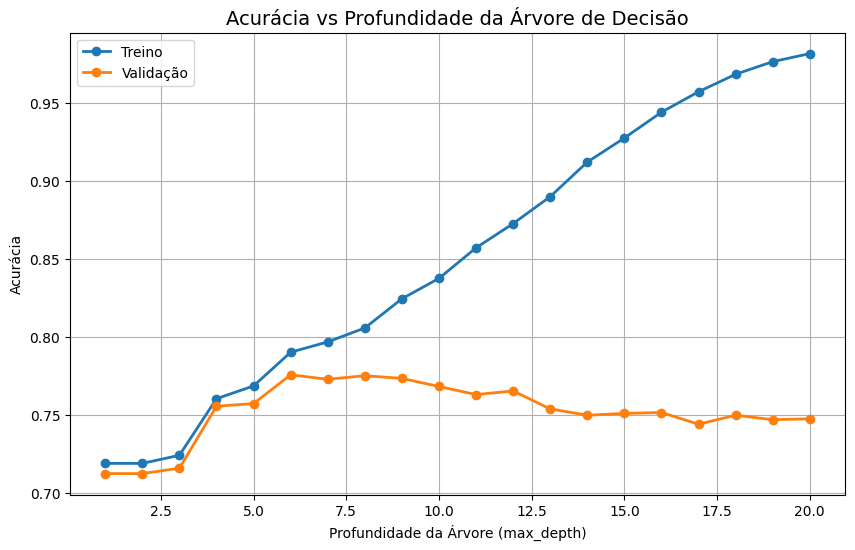

🌳 Profundidade ideal: 6 (melhor acurácia de validação = 0.7757)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# --- 1️⃣ Divisão dos dados (mesmo conjunto que você usa) ---
features = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side',
            'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt',
            'ShoppingMall', 'Spa', 'VRDeck']
target = 'Transported'

X = df_train[features]
y = df_train[target]

categorical_features = ['HomePlanet', 'CryoSleep', 'Cabin_Deck', 'Cabin_Side', 'Destination', 'VIP']
numerical_features = ['Cabin_Num', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('passthrough', 'passthrough', numerical_features)
    ]
)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2️⃣ Testar diferentes profundidades ---
train_accuracies = []
val_accuracies = []
depths = range(1, 21)  # de 1 a 20 níveis

for depth in depths:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    model.fit(X_train, y_train)

    # Avalia no treino e validação
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

# --- 3️⃣ Plotar o gráfico ---
plt.figure(figsize=(10,6))
plt.plot(depths, train_accuracies, marker='o', label='Treino', linewidth=2)
plt.plot(depths, val_accuracies, marker='o', label='Validação', linewidth=2)
plt.title('Acurácia vs Profundidade da Árvore de Decisão', fontsize=14)
plt.xlabel('Profundidade da Árvore (max_depth)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# --- 4️⃣ Mostrar profundidade com melhor acurácia de validação ---
best_depth = depths[val_accuracies.index(max(val_accuracies))]
print(f"🌳 Profundidade ideal: {best_depth} (melhor acurácia de validação = {max(val_accuracies):.4f})")

## AQUI (71)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split # Added back train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# --- 1️⃣ Features e target ---
# Removing categorical features that were previously one-hot encoded
features = ['Cabin_Num', 'Age', 'RoomService', 'FoodCourt',
            'ShoppingMall', 'Spa', 'VRDeck', 'CryoSleep', 'VIP'] # Keeping boolean and numerical
target = 'Transported'

X = df_train[features]
y = df_train[target]

# --- 2️⃣ No preprocessing (removing one-hot encoding) ---
# The data should already be in a suitable format (numerical or boolean)
# based on previous imputation steps.

# --- 3️⃣ Divisão treino/validação ---
# Added back train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# --- 4️⃣ DecisionTree Model ---
model_arvore = DecisionTreeClassifier(random_state=42)

# Train the model on the training split
model_arvore.fit(X_train, y_train) # Changed back to X_train, y_train

print("Decision Tree model trained successfully on the training split!")

# --- 5️⃣ Evaluate on validation set ---
# Added back evaluation on validation set
y_pred_val = model_arvore.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)
print(f"\n🎯 Acurácia no conjunto de validação: {acc_val:.4f}")
print("\n📊 Relatório de classificação no conjunto de validação:")
print(classification_report(y_val, y_pred_val))


# --- 6️⃣ Predição no df_test ---
X_test = df_test[features] # Use the same features

df_test['Transported_Predicted'] = model_arvore.predict(X_test)

print("\nPredictions made successfully on df_test!")
display(df_test[['PassengerId', 'Transported_Predicted']].head())

Decision Tree model trained successfully on the training split!

🎯 Acurácia no conjunto de validação: 0.7165

📊 Relatório de classificação no conjunto de validação:
              precision    recall  f1-score   support

       False       0.72      0.71      0.71       863
        True       0.71      0.73      0.72       876

    accuracy                           0.72      1739
   macro avg       0.72      0.72      0.72      1739
weighted avg       0.72      0.72      0.72      1739


Predictions made successfully on df_test!


,PassengerId,Transported_Predicted
0,0013_01,True
1,0018_01,False
2,0019_01,False
3,0021_01,True
4,0023_01,True


# Baixando as bases para análises no PowerBI

In [ ]:
# Save the dataframes to CSV files
df_train.to_csv('/content/df_train_imputed.csv', index=False)
df_test.to_csv('/content/df_test_imputed.csv', index=False)
df_sub.to_csv('/content/df_sub_imputed.csv', index=False)

print("DataFrames saved to /content/df_train_imputed.csv, /content/df_test_imputed.csv, and /content/df_sub_imputed.csv")

DataFrames saved to /content/df_train_imputed.csv, /content/df_test_imputed.csv, and /content/df_sub_imputed.csv


In [ ]:
# download

from google.colab import files

files.download('/content/df_train_imputed.csv')
files.download('/content/df_test_imputed.csv')
files.download('/content/df_sub_imputed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>